<a href="https://colab.research.google.com/github/ag999git/001-Python-book-2026/blob/main/colab-nb/11_ch11_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: NumPy

This notebook holds the code examples of Chapter 11. You do not need to type them. Run them, read the notes, and then change the code to see what happens.

NumPy is the library that makes Python fast with numbers. This chapter starts with the ideas behind it (vectors, matrices and tensors), then shows how to create arrays, pick out parts of them, reshape and join them, and do arithmetic on whole arrays at once. It ends with linear algebra: solving equations, eigenvalues, and the Singular Value Decomposition, used here to compress an image.

### How this notebook is arranged

- Each code example from the book is in its own code cell.
- Before every example there is a text cell. It tells you what the code does, how it does it, why it matters, and what you should learn from it.
- Some examples also have a text cell after them. Its heading starts with "Notes on Example" and the example number, so you always know which code cell it talks about.
- A few short cells are marked **Try it**. They are not in the book. They let you see, safely, something the book describes in words.
- At the end of every section there is a link that takes you back to the Table of Contents.
- A short "Beyond the Book" section at the end adds a few extras. You can skip it on the first reading.

### How to run the code

1. Click inside a code cell.
2. Press **Shift + Enter**, or click the round Run button on the left of the cell.
3. The result appears just below the cell.

Run the cells from top to bottom. NumPy is already installed in Colab, so `import numpy as np` works straight away.

**About the comments in the code.** Many lines end with a comment such as `# Output: ...`. These show what the book expected. Random numbers, and the exact way NumPy prints decimals, can differ slightly on your computer. Trust the output under the cell.

### How to read the flowcharts

The steps are numbered 1, 2, 3 and so on. When the flow splits into two paths, one path uses the letter A (2A, 3A ...) and the other uses the letter B (2B, 3B ...). A long chain of steps is folded onto a second row: follow the arrow down and back to the left.

## <a name="toc"></a>Table of Contents

- [Learning objectives](#learning-objectives)
- [11.1 Introduction to NumPy and array creation](#11-1-introduction-to-numpy-and-array-creation)
- [11.2 What is NumPy?](#11-2-what-is-numpy)
- [11.3 Installing NumPy](#11-3-installing-numpy)
    - [Try it: checking your NumPy version](#try-it-checking-your-numpy-version)
- [11.4 Understanding vectors, matrices and tensors](#11-4-understanding-vectors-matrices-and-tensors)
    - [Matrix](#matrix)
    - [Axis 0 and axis 1](#axis-0-and-axis-1)
    - [Row vectors and column vectors](#row-vectors-and-column-vectors)
    - [Heterogeneous and homogeneous data inside the cells](#heterogeneous-and-homogeneous-data-inside-the-cells)
    - [Tensors](#tensors)
    - [Try it: the shape of a vector, a matrix and a tensor](#try-it-the-shape-of-a-vector-a-matrix-and-a-tensor)
- [11.5 Python lists and NumPy speed: the "why"](#11-5-python-lists-and-numpy-speed-the-why)
    - [Try it: timing a list against an array](#try-it-timing-a-list-against-an-array)
- [11.6 Creating NumPy arrays](#11-6-creating-numpy-arrays)
    - [11.6.1 Introduction](#11-6-1-introduction)
    - [The common creation functions](#the-common-creation-functions)
    - [Signatures of some common creation functions](#signatures-of-some-common-creation-functions)
    - [Example 1: The basic ways of creating arrays](#example-1-the-basic-ways-of-creating-arrays)
    - [Example 2: Working on the whole array at once](#example-2-working-on-the-whole-array-at-once)
    - [Example 3: A mixed-type array (and why to avoid it)](#example-3-a-mixed-type-array-and-why-to-avoid-it)
- [11.7 Array indexing in NumPy](#11-7-array-indexing-in-numpy)
    - [Differences from Python lists](#differences-from-python-lists)
    - [Example 4: Indexing and slicing a 2D array](#example-4-indexing-and-slicing-a-2d-array)
    - [Notes on Example 4](#notes-on-example-4)
- [11.8 Operations along an axis in NumPy](#11-8-operations-along-an-axis-in-numpy)
    - [Example 5: sum() along axis 0 and axis 1](#example-5-sum-along-axis-0-and-axis-1)
- [11.9 Random array functions in NumPy](#11-9-random-array-functions-in-numpy)
    - [Example 6: Right and wrong use of the random functions](#example-6-right-and-wrong-use-of-the-random-functions)
    - [Notes on Example 6](#notes-on-example-6)
- [11.10 Reshaping arrays](#11-10-reshaping-arrays)
    - [11.10.1 Methods for reshaping](#11-10-1-methods-for-reshaping)
    - [Example 7: reshape() and flatten()](#example-7-reshape-and-flatten)
    - [Transposing an array](#transposing-an-array)
    - [Example 8: Transposing a matrix and a vector](#example-8-transposing-a-matrix-and-a-vector)
    - [Try it: a 3D transpose, and a real column vector](#try-it-a-3d-transpose-and-a-real-column-vector)
- [11.11 Broadcasting in NumPy](#11-11-broadcasting-in-numpy)
    - [Example 9: Broadcasting a scalar, a row vector and a column vector](#example-9-broadcasting-a-scalar-a-row-vector-and-a-column-ve)
    - [11.11.1 Broadcasting rules (simple version)](#11-11-1-broadcasting-rules-simple-version)
    - [Try it: checking the rules](#try-it-checking-the-rules)
- [11.12 Vectorization (the "why")](#11-12-vectorization-the-why)
    - [11.12.1 The three pillars of vectorization](#11-12-1-the-three-pillars-of-vectorization)
    - [Example 10: The three pillars in one script](#example-10-the-three-pillars-in-one-script)
    - [11.12.2 The golden rules of vectorization](#11-12-2-the-golden-rules-of-vectorization)
    - [11.12.3 When is a loop acceptable?](#11-12-3-when-is-a-loop-acceptable)
    - [Try it: a loop against a vectorized square root](#try-it-a-loop-against-a-vectorized-square-root)
- [11.13 Advanced indexing and selection](#11-13-advanced-indexing-and-selection)
    - [11.13.1 Integer array indexing](#11-13-1-integer-array-indexing)
    - [11.13.2 Boolean masking (filtering)](#11-13-2-boolean-masking-filtering)
    - [11.13.3 np.where() (conditional transformation)](#11-13-3-np-where-conditional-transformation)
    - [Example 11: Integer indexing, boolean masking and np.where()](#example-11-integer-indexing-boolean-masking-and-np-where)
    - [Notes on Example 11](#notes-on-example-11)
- [11.14 Joining arrays](#11-14-joining-arrays)
- [11.15 Breaking arrays: splitting](#11-15-breaking-arrays-splitting)
    - [Example 12: Joining and splitting the marks of two classes](#example-12-joining-and-splitting-the-marks-of-two-classes)
    - [Try it: np.stack() adds a new axis](#try-it-np-stack-adds-a-new-axis)
- [11.16 Scientific computing in NumPy](#11-16-scientific-computing-in-numpy)
    - [Example 13: Trigonometry, logarithms and statistics](#example-13-trigonometry-logarithms-and-statistics)
- [11.17 Generating grids: linspace() and meshgrid()](#11-17-generating-grids-linspace-and-meshgrid)
    - [Example 14: Building a grid with linspace() and meshgrid()](#example-14-building-a-grid-with-linspace-and-meshgrid)
    - [Try it: a 3D surface from a grid](#try-it-a-3d-surface-from-a-grid)
- [11.18 Special numerical values in NumPy](#11-18-special-numerical-values-in-numpy)
    - [Example 15: inf, -inf and nan](#example-15-inf-inf-and-nan)
    - [Try it: testing for nan and inf](#try-it-testing-for-nan-and-inf)
- [11.19 Basic matrix operations in NumPy](#11-19-basic-matrix-operations-in-numpy)
    - [Example 16: Transpose, determinant, inverse, norm, rank and matrix product](#example-16-transpose-determinant-inverse-norm-rank-and-matri)
    - [Try it: trace, and * compared with @](#try-it-trace-and-compared-with)
- [11.20 Solving linear equations with NumPy](#11-20-solving-linear-equations-with-numpy)
    - [Example 17: Solving three equations in three unknowns](#example-17-solving-three-equations-in-three-unknowns)
- [11.21 Eigenvalues and eigenvectors](#11-21-eigenvalues-and-eigenvectors)
    - [Try it: eigenvalues with np.linalg.eig()](#try-it-eigenvalues-with-np-linalg-eig)
- [11.22 Introduction to Singular Value Decomposition (SVD)](#11-22-introduction-to-singular-value-decomposition-svd)
    - [Try it: SVD of a small matrix](#try-it-svd-of-a-small-matrix)
- [Questions](#questions)
- [Beyond the text: image compression with SVD](#beyond-the-text-image-compression-with-svd)
    - [Example 18: Compressing an image with SVD](#example-18-compressing-an-image-with-svd)
    - [Notes on Example 18](#notes-on-example-18)
- [Beyond the Book](#beyond-the-book)
    - [The modern random generator: default_rng()](#the-modern-random-generator-default-rng)
    - [A few handy functions: unique, clip, argmax and newaxis](#a-few-handy-functions-unique-clip-argmax-and-newaxis)
    - [Saving and loading arrays](#saving-and-loading-arrays)

## <a name="learning-objectives"></a>Learning objectives

By the end of this chapter you should be able to:

- explain why a NumPy `ndarray` is faster and uses less memory than a Python list (one continuous block of memory, handled in C);
- describe vectors, matrices and tensors, use zero-based indexing, and follow the "axis 0 is rows, axis 1 is columns" rule;
- create arrays with `np.array`, `zeros`, `ones`, `eye`, `arange` and `linspace`;
- index and slice with `arr[i, j]`, including several dimensions at once, and know when you get a view and when a copy;
- use broadcasting and universal functions to do arithmetic on arrays of different shapes;
- build coordinate grids with `np.meshgrid` for 3D plots and surfaces;
- use `np.linalg` for matrix operations and for solving systems of linear equations;
- compute and interpret eigenvalues and eigenvectors;
- understand what the Singular Value Decomposition (SVD) does, and use it to compress an image with the PIL library.

[Back to the Table of Contents](#toc)

## <a name="11-1-introduction-to-numpy-and-array-creation"></a>11.1 Introduction to NumPy and array creation

Python, together with packages like NumPy, SciPy and Matplotlib, is a powerful, free alternative to MATLAB for scientific computing. **NumPy** stands for "Numerical Python". It is the basic package for numbers in Python. It gives you large, multi-dimensional arrays and matrices, and a big library of fast mathematical functions that work on them.

Many other libraries are built on top of NumPy:

| Library | Built on NumPy for |
|---|---|
| Pandas | Data analysis |
| SciPy | Scientific computing |
| Scikit-learn | Machine learning |
| Matplotlib | Data visualisation |
| TensorFlow, Keras | Deep learning |

[Back to the Table of Contents](#toc)

## <a name="11-2-what-is-numpy"></a>11.2 What is NumPy?

NumPy (Numerical Python) is a core library for scientific computing. It supports large multi-dimensional arrays and matrices, and a collection of functions that work on them efficiently. It is the foundation of most data science libraries, such as Pandas, SciPy and Scikit-learn.

It was created by Travis Oliphant in 2005, by combining two older libraries, Numeric and Numarray.

| Characteristic | Description |
|---|---|
| Open source | Free to use and distribute |
| High performance | Written in C, optimised for speed |
| Memory efficient | Stores data in one continuous block of memory |
| Interoperable | Works well with other Python libraries |
| Multi-dimensional | Supports arrays of any number of dimensions |

[Back to the Table of Contents](#toc)

## <a name="11-3-installing-numpy"></a>11.3 Installing NumPy

NumPy must be installed before you can use it. In Colab it is already installed. On your own computer, use one of these:

| Method | Command | Best for |
|---|---|---|
| pip | `pip install numpy` | General use |
| conda | `conda install numpy` | Anaconda users |
| From source | `python setup.py install` | Advanced users |
| requirements.txt | `pip install -r requirements.txt` | Setting up a whole project |

[Back to the Table of Contents](#toc)

### <a name="try-it-checking-your-numpy-version"></a>Try it: checking your NumPy version

This cell is not in the book. It imports NumPy under its usual short name `np` and prints the version installed.

In [1]:
import numpy as np
print("NumPy version:", np.__version__)

NumPy version: 2.0.2


[Back to the Table of Contents](#toc)

## <a name="11-4-understanding-vectors-matrices-and-tensors"></a>11.4 Understanding vectors, matrices and tensors

Vectors, matrices and tensors come from mathematics. It is worth understanding them first, because a NumPy array is simply a software version of a mathematical tensor. Once you know the shapes, NumPy code becomes easy to follow.

[Back to the Table of Contents](#toc)

### <a name="matrix"></a>Matrix

Think of a **matrix** as a spreadsheet. It has rows and columns, and the data sits where a row meets a column (a **cell**).

**Zero-based indexing.** In Python and NumPy, rows and columns are counted from 0. So the top-left cell has the index **(0, 0)**. A table of 3 rows and 4 columns has rows 0 to 2 and columns 0 to 3. Each cell's address is the pair `(row_number, column_number)`.

**Data and addresses.** If a matrix is called X, the data in row i and column j is written X<sub>i,j</sub>. In Python code this becomes `X[i, j]`.

| | Column 0 | Column 1 | Column 2 | Column 3 |
|---|---|---|---|---|
| **Row 0** | X<sub>0,0</sub> | X<sub>0,1</sub> | X<sub>0,2</sub> | X<sub>0,3</sub> |
| **Row 1** | X<sub>1,0</sub> | X<sub>1,1</sub> | X<sub>1,2</sub> | X<sub>1,3</sub> |
| **Row 2** | X<sub>2,0</sub> | X<sub>2,1</sub> | X<sub>2,2</sub> | X<sub>2,3</sub> |

**An example.** Suppose you keep the marks of all the students in a class. By convention, each **student is a row** and each **subject is a column**.

- A row is one "entity". In databases, rows are also called tuples or records.
- A column is one "feature". In databases, columns are called fields or attributes.

With 3 students and 4 subjects you get 3 rows (index 0 to 2) and 4 columns (index 0 to 3). Then X<sub>i,j</sub> holds the marks of the (i+1)th student in the (j+1)th subject. The index is one less than the count, because counting starts at 0.

[Back to the Table of Contents](#toc)

### <a name="axis-0-and-axis-1"></a>Axis 0 and axis 1

In a matrix, **axis 0** runs down the rows (top to bottom), and **axis 1** runs across the columns (left to right).

Be careful: this is not the school geometry picture, where the x-axis goes left to right and the y-axis goes bottom to top. In data science and matrix algebra, the first index is always the row (going down), and the second is the column (going right).

[Back to the Table of Contents](#toc)

### <a name="row-vectors-and-column-vectors"></a>Row vectors and column vectors

- **Row vector:** a class with only one student gives a table with a single row and many columns: [X<sub>0,0</sub> X<sub>0,1</sub> X<sub>0,2</sub> X<sub>0,3</sub>]. So a vector is a matrix with a single row: one entity with many features.
- **Column vector:** now look at one subject for all students. That is a single column, with one value per row. A column vector is often written as a row with a "T" (transpose) mark.

[Back to the Table of Contents](#toc)

### <a name="heterogeneous-and-homogeneous-data-inside-the-cells"></a>Heterogeneous and homogeneous data inside the cells

In a spreadsheet, a teacher may put marks in some columns and text (such as "Boy/Girl" or an address) in others. That is **heterogeneous** (mixed) data. A mathematical matrix, and so a NumPy array, holds **homogeneous** data: every cell has exactly the same type (all integers, or all floats). If you mix text and numbers, NumPy turns everything into text.

[Back to the Table of Contents](#toc)

### <a name="tensors"></a>Tensors

When there are more than 2 dimensions, the object is called a **tensor**. Take the school example further. Every class has the same subjects, and the teacher prints one spreadsheet of marks per class. Stacking these sheets on top of each other gives a 3D block: a tensor. The new direction, the stack, becomes **axis 0**; rows become axis 1, and columns axis 2.

| Object | Dimensions | Example shape | Meaning |
|---|---|---|---|
| Vector | 1 | `(4,)` | one row of 4 marks |
| Matrix | 2 | `(4, 3)` | 4 students, 3 subjects |
| Tensor | 3 | `(2, 4, 3)` | 2 classes, each with 4 students and 3 subjects |

[Back to the Table of Contents](#toc)

### <a name="try-it-the-shape-of-a-vector-a-matrix-and-a-tensor"></a>Try it: the shape of a vector, a matrix and a tensor

This cell is not in the book. `ndim` gives the number of dimensions (axes) and `shape` gives the size along each axis.

In [2]:
import numpy as np

vector = np.array([90, 85, 70, 60])                  # 1 student, 4 subjects
matrix = np.array([[90, 85, 70],
                   [60, 75, 80],
                   [55, 65, 95],
                   [88, 92, 79]])                     # 4 students, 3 subjects
tensor = np.array([matrix, matrix + 5])               # 2 classes stacked

for name, a in [("vector", vector), ("matrix", matrix), ("tensor", tensor)]:
    print(f"{name}: ndim = {a.ndim}, shape = {a.shape}")

print("Class 1, student 2, subject 0:", tensor[1, 2, 0])

vector: ndim = 1, shape = (4,)
matrix: ndim = 2, shape = (4, 3)
tensor: ndim = 3, shape = (2, 4, 3)
Class 1, student 2, subject 0: 60


The online resource has a project on row vectors and column vectors: how they are built in NumPy, how they differ from lists and 1D arrays, why geometric transformations use column vectors, and examples of rotation and scaling.

[Back to the Table of Contents](#toc)

## <a name="11-5-python-lists-and-numpy-speed-the-why"></a>11.5 Python lists and NumPy speed: the "why"

Python lists are flexible, but they are not built for heavy maths. The main difference is how data is stored in memory.

- **Python lists:** a list is really an array of **pointers**. Each item can be a different type (an integer, a string, a boolean), so Python stores each one as a separate object somewhere in memory and keeps a pointer to it. Jumping around memory makes loops slow.
- **NumPy arrays:** strictly homogeneous. Because NumPy knows the type of every element, it stores the data in **one continuous block** of memory, as a C array. The processor can then work through the data very fast, without checking the type of each element.

In short, a NumPy array (`ndarray`) (1) holds elements of one data type (`dtype`), (2) keeps them in contiguous memory, which is very fast, and (3) supports vectorised operations, with no loops needed.

| Aspect | Python list | NumPy array |
|---|---|---|
| Memory storage | Scattered locations | One contiguous block |
| Data type | Can mix types | One data type |
| Operation speed | Slow for large data | Optimised C-level operations |
| Element-wise operations | Need loops | Built-in vectorisation |
| Memory overhead | High (a full object per element) | Low (fixed-size elements) |

[Back to the Table of Contents](#toc)

### <a name="try-it-timing-a-list-against-an-array"></a>Try it: timing a list against an array

This cell is not in the book. It adds up the squares of one million numbers, first with a list and a loop, then with a NumPy array. Your times will differ, but NumPy is usually many times faster.

In [3]:
import time
import numpy as np

n = 1_000_000
numbers = list(range(n))
array = np.arange(n)

start = time.perf_counter()
total_list = sum(x * x for x in numbers)
t_list = time.perf_counter() - start

start = time.perf_counter()
total_np = np.sum(array * array)
t_np = time.perf_counter() - start

print("Same answer?", total_list == total_np)
print(f"List : {t_list:.4f} s")
print(f"NumPy: {t_np:.4f} s")
print(f"NumPy was about {t_list / t_np:.0f} times faster")

Same answer? True
List : 0.0329 s
NumPy: 0.0037 s
NumPy was about 9 times faster


The online resource has a full script that compares arrays and lists for memory, data types, operations and speed.

[Back to the Table of Contents](#toc)

## <a name="11-6-creating-numpy-arrays"></a>11.6 Creating NumPy arrays

### <a name="11-6-1-introduction"></a>11.6.1 Introduction

Most arrays are created in one of five ways:

| Way | Functions |
|---|---|
| 1. From existing data | `np.array()`, `np.asarray()`, `np.fromiter()`, `np.fromfunction()`, `np.loadtxt()` |
| 2. Basic arrays | `np.zeros()`, `np.ones()`, `np.full()`, `np.empty()`, `np.zeros_like()`, `np.ones_like()`, `np.full_like()` |
| 3. Sequences | `np.arange()`, `np.linspace()`, `np.logspace()` |
| 4. Special matrices | `np.identity()`, `np.eye()`, `np.diag()`, `np.indices()`, `np.meshgrid()` |
| 5. Random arrays | `np.random.rand()`, `np.random.randint()`, `np.random.randn()`, `np.random.choice()`, `np.random.uniform()` |

Beginners usually start with a handful of them: `np.array()`, `np.zeros()`, `np.ones()`, `np.full()`, `np.arange()` and `np.linspace()`. These cover most real tasks.

[Back to the Table of Contents](#toc)

### <a name="the-common-creation-functions"></a>The common creation functions

| Function and purpose | Input | Example | Key property | Typical use |
|---|---|---|---|---|
| `np.array()`: turn Python data into an array | A list, tuple or nested list | `np.array([1, 2, 3])` | Works out the `dtype` automatically | Converting existing data |
| `np.zeros()`: array of zeros | A shape | `np.zeros((3, 2))` | The default type is float | Starting values |
| `np.ones()`: array of ones | A shape | `np.ones((2, 3))` | | Machine learning, matrices |
| `np.full()`: array of one constant value | A shape and a value | `np.full((2, 2), 9)` | | Default or fixed values |
| `np.arange()`: sequence by step size | Start, stop, step | `np.arange(0, 10, 2)` | Like `range()`, but returns an array | Number sequences |
| `np.linspace()`: evenly spaced numbers | Start, stop, how many | `np.linspace(0, 1, 5)` | Includes the end value | Plotting, interpolation |
| `np.eye()`: identity matrix | Size | `np.eye(3)` | 1 on the diagonal, 0 elsewhere | Linear algebra |
| `np.random.rand()`: random floats | Dimensions | `np.random.rand(3)` | Values in [0, 1) | Simulations |

SciPy is built on top of NumPy, so an array made with `np.array()` can be passed straight to any SciPy function. The array-creation functions themselves live in NumPy, not in SciPy.

[Back to the Table of Contents](#toc)

### <a name="signatures-of-some-common-creation-functions"></a>Signatures of some common creation functions

| Signature | What it does |
|---|---|
| `numpy.array(alist)` | Makes an array (of type `ndarray`) from a list. Note that `numpy.array` is a function; the object it creates is an `ndarray`. |
| `numpy.zeros((N, M), dtype=float)` | An array of the given shape, here N x M, filled with 0. |
| `numpy.ones((N, M), dtype=float)` | An array of the given shape, here N x M, filled with 1. |
| `numpy.eye(N, M=None, dtype=float)` | A 2D array with 1 on the diagonal and 0 elsewhere. If `M` is left out it equals `N`, giving a square matrix. |
| `numpy.transpose(a, axes=None)` | Swaps the dimensions of array `a`. With no `axes`, the order of the dimensions is reversed, so a 2 x 5 matrix becomes 5 x 2. |
| `numpy.arange(start, stop, step)` | Like Python's `range()`, but start, stop and step may be decimals. |
| `numpy.random.random((N, M))` | An N x M array of random numbers in [0, 1): 0 can appear, 1 never does. |
| `numpy.random.randint(X, Y, (N, M))` | An N x M array of random integers from X up to, but not including, Y. |

[Back to the Table of Contents](#toc)

### <a name="example-1-the-basic-ways-of-creating-arrays"></a>Example 1: The basic ways of creating arrays

**What the code does.** It creates arrays in five ways: (1) from Python data (a list, a tuple, a nested list), (2) filled with a default value (`zeros`, `ones`, `full`), (3) as sequences (`arange`, `linspace`), (4) as a special matrix (`eye`), and (5) with random numbers (`rand`, after `seed`).

**How it works.** Each function returns a new `ndarray`. NumPy picks the data type for you: whole numbers give an integer array, and anything with a decimal point gives a float array.

**Learning points**

1. `np.array([10, 20, 30, 40])` gives integers, but the tuple `(1.5, 2.5, 3.5)` gives floats.
2. `np.zeros(5)` prints `[0. 0. 0. 0. 0.]`. The dot shows the values are floats, the default type.
3. A shape of several dimensions is given as a tuple: `np.ones((2, 3))`.
4. `np.arange(0, 10, 2)` stops **before** 10. `np.linspace(0, 1, 5)` **includes** 1.
5. `np.random.seed(0)` makes the "random" numbers the same on every run.

In [4]:
# Script: Basic Array Creation in NumPy
import numpy as np

# 1. Creating Arrays from Existing Data
# 1.1 From list
data_list = [10, 20, 30, 40]
arr1 = np.array(data_list)  # NumPy array from Python list.
print("From list:->", arr1)
# 1.2 From tuple
data_tuple = (1.5, 2.5, 3.5)
arr2 = np.array(data_tuple)  # NumPy array from Python tuple.
print("From tuple:->", arr2)
# 1.3 2D array
matrix = np.array([[1, 2, 3], [4, 5, 6]])  # 2D NumPy array from nested list
print("2D array:->\n", matrix)

# 2. Creating Arrays with Default Values
# 2.1 Zeros
zeros = np.zeros(5)  # NumPy array filled with zeros.
print("Zeros:->", zeros)
# 2.2 Ones
ones = np.ones((2, 3))  # NumPy array filled with ones.
print("Ones:->\n", ones)
# 2.3 Constant value
const = np.full(4, 9)  # NumPy array filled with a constant value.
print("Full (Filled with 9s):->", const)

# 3. Creating Sequence Arrays
# 3.1 arange
seq1 = np.arange(0, 10, 2)  # NumPy array with a range of values.
print("arange:->", seq1)
# 3.2 linspace
seq2 = np.linspace(0, 1, 5)  # NumPy array with linearly spaced values
print("linspace:->", seq2)

# 4. Creating Special Matrices
# 4.1 Identity matrix
identity = np.eye(3)  # NumPy array representing 3x3 identity matrix
print("Identity matrix:->\n", identity)

# 5. Creating Random Numbers
# 5.1 Random floats
np.random.seed(0)
rand_nums = np.random.rand(5)  # NumPy array with random floats.
print("Random floats:->", rand_nums)

From list:-> [10 20 30 40]
From tuple:-> [1.5 2.5 3.5]
2D array:->
 [[1 2 3]
 [4 5 6]]
Zeros:-> [0. 0. 0. 0. 0.]
Ones:->
 [[1. 1. 1.]
 [1. 1. 1.]]
Full (Filled with 9s):-> [9 9 9 9]
arange:-> [0 2 4 6 8]
linspace:-> [0.   0.25 0.5  0.75 1.  ]
Identity matrix:->
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Random floats:-> [0.5488135  0.71518937 0.60276338 0.54488318 0.4236548 ]


[Back to the Table of Contents](#toc)

### <a name="example-2-working-on-the-whole-array-at-once"></a>Example 2: Working on the whole array at once

**What the code does.** It builds a list of squares with a list comprehension, turns it into an array, and then adds, multiplies, raises to a power and divides the **whole array** in one step each.

**How it works.** An arithmetic operator between an array and a number is applied to every element. No loop is written; NumPy runs the loop in C.

**Learning points**

1. `np_array + 10` would fail on a list (`[0, 1, 4] + 10` is a `TypeError`), but works on an array.
2. `*` on a list repeats it; on an array it multiplies each element. Compare `[1, 2] * 2` with `np.array([1, 2]) * 2`.
3. Division `/` always gives floats, shown with a dot: `[0.  0.5 2. ...]`.

In [5]:
list_squares = [n*n for n in range(5)]   # [0, 1, 4, 9, 16]
np_array = np.array(list_squares)   # Convert to NumPy array
print(np_array + 10)  # [10 11 14 19 26] - element-wise addition
print(np_array * 2)   # [0 2 8 18 32] - element-wise multiplication
print(np_array ** 2)  # [0 1 16 81 256] - element-wise exponentiation
print(np_array / 2)   # [0. 0.5 2. 4.5 8.] - element-wise division

[10 11 14 19 26]
[ 0  2  8 18 32]
[  0   1  16  81 256]
[0.  0.5 2.  4.5 8. ]


[Back to the Table of Contents](#toc)

### <a name="example-3-a-mixed-type-array-and-why-to-avoid-it"></a>Example 3: A mixed-type array (and why to avoid it)

**What the code does.** It forces NumPy to keep an integer, a string and a boolean in one array by passing `dtype=object`. It prints the array's `dtype` and then the type of each element.

**How it works.** With `dtype=object`, each element is stored as an ordinary Python object, with a pointer, just like a list. So the array is no longer a compact block of numbers.

**Why it matters.** NumPy prefers homogeneous data. Mixed arrays are allowed, but they (1) run slowly and (2) lose NumPy's advantages. Use them only if you have to.

**Learning points**

1. `mixed_array.dtype` prints `object`, not the values.
2. Each element keeps its own Python type: `int`, `str` and `bool`.
3. **Try it:** remove `, dtype=object`. NumPy then turns everything into text, and `dtype` shows something like `<U21` (Unicode strings).

In [6]:
# Mixed data types in a NumPy array. Not good for numerical computations
mixed_array = np.array([1, "cat", True], dtype=object)
print(mixed_array.dtype)   # object
# printing type of each element in the mixed array
for element in mixed_array:
    print(type(element))  # <class 'int'>, <class 'str'>, <class 'bool'>

object
<class 'int'>
<class 'str'>
<class 'bool'>


The online resource has a detailed list of NumPy array-creation functions at three levels (beginner, intermediate and advanced), and a complete map of array creation.

[Back to the Table of Contents](#toc)

## <a name="11-7-array-indexing-in-numpy"></a>11.7 Array indexing in NumPy

Indexing means picking elements of an array with square brackets `[]`.

| No. | Property |
|---|---|
| 1 | **1D arrays** work exactly like Python lists, with positive and negative indexes. |
| 2 | **Several dimensions:** NumPy allows `arr[i][j]` (list style) and `arr[i, j]` (NumPy style). The NumPy style is cleaner and faster, and is preferred. |
| 3 | **Slicing** uses `start : stop : step`, separately for each axis: `arr[rows, columns]`. A lone colon `:` means "all". Examples: `arr[0]` is the first row, `arr[:, 1]` the second column, `arr[::2, :]` every second row. |
| 4 | **View, not copy (very important):** a slice is a view of the same data. Changing the slice changes the original array. |
| 5 | **Key points:** use `arr[i, j]` rather than `arr[i][j]`; use `:` to select whole rows or columns; be careful, because changing a slice changes the original data. |

[Back to the Table of Contents](#toc)

### <a name="differences-from-python-lists"></a>Differences from Python lists

| Feature | Python list | NumPy array |
|---|---|---|
| Indexing in several dimensions | Nested only: `lst[i][j]` | `arr[i, j]` |
| Selecting a column | No direct way | `arr[:, j]` |
| Slicing | One dimension only | Many dimensions at once |
| Performance | Slower | Faster |

[Back to the Table of Contents](#toc)

### <a name="example-4-indexing-and-slicing-a-2d-array"></a>Example 4: Indexing and slicing a 2D array

**What the code does.** It builds a 4 x 3 array holding 0 to 11 and then shows: (1) basic indexing, including negative indexes, (2) picking a whole row or a whole column, (3) slicing a sub-matrix and taking every second row or column, (4) how a slice is a **view** that shares data with the original, and (5) two lines, commented out, that would raise errors.

**How it works.** `np.arange(12).reshape(4, 3)` makes the numbers 0 to 11 and arranges them in 4 rows of 3. In `arr[1:3, 0:2]` the first slice picks rows 1 and 2, and the second picks columns 0 and 1. As with lists, the stop value is not included.

**Why it matters.** Almost every NumPy program picks out parts of arrays. The view behaviour is the most common source of surprises.

**Learning points**

1. `arr[0, 1]` and `arr[0][1]` give the same element.
2. `arr[:, 1]` gives the column as a 1D array: `[ 1  4  7 10]`.
3. After `sub[0, 0] = 999`, the original `arr` also shows 999, because `sub` is a view.
4. If you need an independent copy, write `arr[0:2, :].copy()`.

![Slicing gives a view; integer indexing and masking give a copy](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-01-view-vs-copy.png)

In [7]:
import numpy as np
# Create 2D array
arr = np.arange(12).reshape(4,3)  # 4 rows, 3 columns
print("Original array:\n", arr)
# Output: [[ 0  1  2]
#          [ 3  4  5]
#          [ 6  7  8]
#          [ 9 10 11]]

# 1. Basic Indexing for 2D arrays
print("NumPy style:", arr[0, 1])     # NumPy style: arr[row, col]. Output: 1
print("Python style:", arr[0][1]) # Python style: arr[row][col]. Output: 1
# Negative indexing for 2D array (-1) -> last row/col, (-2) -> second last etc
print("Negative indexing:", arr[-1, -1]) #
# row -1 (last row), col -1 (last column). Output: 11

# 2. Row & Column Access for 2D arrays
print("First row:", arr[0])  # row 0. Output: [0 1 2]
print("Second column:", arr[:, 1])  # all rows, column 1. Output: [1 4 7 10]

# 3. Slicing for 2D arrays
print("Sub-matrix:\n", arr[1:3, 0:2])   # rows 1-2, cols 0-1. Output: [[3 4]
#                                                                    [6 7]]
print("Every 2nd row:\n", arr[::2, :]) # Output: [[ 0  1  2]
#                                                 [ 6  7  8]]
print("Every 2nd col:\n", arr[:, ::2]) # Output: [[ 0  2].
#  all rows every 2nd column                      [ 3  5]
#  columns at index 0 and 2                       [ 6  8]
#                                                 [ 9 11]]

# 4. View Behavior of Slices
sub = arr[0:2, :]        # slice (view)
sub[0,0] = 999           # modifies original array
print("Modified array:\n", arr)  # adds 999 to arr[0,0].

# 5. Error / Misuse Examples
# arr[1,2,3]   # too many indices. arr is 2D, so max 2 indices allowed
# arr[10]      # index out of bounds. arr has only 4 rows (0-3)

Original array:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
NumPy style: 1
Python style: 1
Negative indexing: 11
First row: [0 1 2]
Second column: [ 1  4  7 10]
Sub-matrix:
 [[3 4]
 [6 7]]
Every 2nd row:
 [[0 1 2]
 [6 7 8]]
Every 2nd col:
 [[ 0  2]
 [ 3  5]
 [ 6  8]
 [ 9 11]]
Modified array:
 [[999   1   2]
 [  3   4   5]
 [  6   7   8]
 [  9  10  11]]


[Back to the Table of Contents](#toc)

### <a name="notes-on-example-4"></a>Notes on Example 4

- **Try it:** remove the `#` in front of `arr[1,2,3]` and run the cell. You get `IndexError: too many indices for array`. Put the `#` back, and try `arr[10]` the same way.
- **Try it:** change `sub = arr[0:2, :]` to `sub = arr[0:2, :].copy()`. Now `arr` keeps its 0.

[Back to the Table of Contents](#toc)

## <a name="11-8-operations-along-an-axis-in-numpy"></a>11.8 Operations along an axis in NumPy

Many NumPy functions, such as `sum()`, `mean()`, `std()`, `min()`, `max()` and `prod()`, take an `axis` argument. Instead of working on the whole array, they then work row by row or column by column.

**Core principle:** the axis tells NumPy which direction to **collapse**.

For `arr.operation(axis=k)`, NumPy (1) moves along axis k, (2) combines the values it meets in that direction, and (3) returns a result in which axis k has disappeared.

| Call | What is collapsed | Result |
|---|---|---|
| `axis=0` | the rows | one value per column |
| `axis=1` | the columns | one value per row |
| no axis | everything | one single value |

**Why does the shape shrink?** Because the chosen axis is squeezed into a single value, that dimension is removed. A (2, 3) array summed along axis 0 gives shape (3,).

![What sum() does along axis 0 and along axis 1](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-02-axis-collapse.png)

[Back to the Table of Contents](#toc)

### <a name="example-5-sum-along-axis-0-and-axis-1"></a>Example 5: sum() along axis 0 and axis 1

**What the code does.** For the 2 x 3 table `[[1, 2, 3], [4, 5, 6]]`, it adds down each column (`axis=0`) and across each row (`axis=1`).

**Learning points**

1. `axis=0` gives three values (one per column): 1+4, 2+5, 3+6.
2. `axis=1` gives two values (one per row): 1+2+3 and 4+5+6.
3. `np.sum()` accepts a plain nested list; NumPy turns it into an array first.
4. The same idea works for `mean()`, `std()`, `min()`, `max()` and `prod()`.

In [8]:
import numpy as np

arr = [[1, 2, 3],
       [4, 5, 6]]

sum_axis0 = np.sum(arr, axis=0)  # Sum along columns (down each column)
print("Sum along axis 0 (columns):", sum_axis0)  # [(1+4=5)  (2+5=7)  (3+6=9)]
sum_axis1 = np.sum(arr, axis=1)  # Sum along rows (across each row)
print("Sum along axis 1 (rows):", sum_axis1)  # [(1+2+3=6) (4+5+6=15)]

Sum along axis 0 (columns): [5 7 9]
Sum along axis 1 (rows): [ 6 15]


The online resource explains 3D arrays and axis operations: the meaning of axes 0, 1 and 2, and how `sum(axis=0)`, `sum(axis=1)` and `sum(axis=2)` reduce a 3D array.

[Back to the Table of Contents](#toc)

## <a name="11-9-random-array-functions-in-numpy"></a>11.9 Random array functions in NumPy

The `numpy.random` module creates random numbers and random arrays. They are used in (1) simulations, (2) data analysis, (3) machine learning, and (4) testing.

The numbers are **pseudo-random**: they look random but come from a fixed algorithm. So `np.random.seed(0)` makes them repeatable: the same seed always gives the same numbers.

| No. | Function | Distribution and range | How the shape is given | Output | Typical use | Example | Wrong use |
|---|---|---|---|---|---|---|---|
| 1 | `np.random.seed()` | Not a generator; sets the starting point | An integer seed | None | Repeatable experiments, debugging, teaching | `np.random.seed(0)` | `np.random.seed("abc")`: the seed must be an integer |
| 2 | `np.random.random()` | Uniform, [0, 1) | A tuple, `size=` | float array | Same as `rand()`, with a more consistent style | `np.random.random((2, 3))` | `np.random.random(2, 3)`: expects one tuple |
| 3 | `np.random.rand()` | Uniform, [0, 1) | Separate numbers, not a tuple | float array | Probabilities, simulations, starting values | `np.random.rand(2, 3)` | `np.random.rand((2, 3))`: a tuple is not allowed |
| 4 | `np.random.randint()` | Discrete uniform, [low, high) | A tuple | integer array | IDs, categories, indexing | `np.random.randint(1, 5, (2, 3))` | `np.random.randint(5, 1, (2, 3))`: low must be less than high |
| 5 | `np.random.randn()` | Standard normal: mean 0, std 1 | Separate numbers | float array | Noise, machine learning, statistics | `np.random.randn(3)` | `np.random.randn((3,))`: a tuple is not allowed |
| 6 | `np.random.choice()` | Picks from a given array | `size=` | sampled array | Sampling, bootstrapping, simulations | `np.random.choice([10, 20, 30], size=2)` | `np.random.choice([], size=2)`: the input cannot be empty |
| 7 | `np.random.uniform()` | Uniform, [low, high) | `size=` | float array | Ranges other than [0, 1) | `np.random.uniform(5, 10, (2, 3))` | `np.random.uniform(0, 1, -3)`: negative dimensions are not allowed |
| 8 | `np.random.normal()` | Normal, with your own mean (`loc`) and std (`scale`) | `size=` | float array | Modelling real data, ML, noise | `np.random.normal(0, 1, (3,))` | `np.random.normal(0, -1, 3)`: std cannot be negative |

Note: a small sample from `randn()` will rarely have a mean of exactly 0. See the note after the example.

[Back to the Table of Contents](#toc)

### <a name="example-6-right-and-wrong-use-of-the-random-functions"></a>Example 6: Right and wrong use of the random functions

**What the code does.** It calls each of the eight functions correctly and prints the result. After each correct line there is a wrong one, commented out, with the error it would give.

**How it works.** `np.random.seed(0)` is set once at the start. Every later call continues the same sequence, so the whole cell gives the same numbers every time you run it.

**Learning points**

1. Watch how the shape is given: `rand(2, 2)` and `randn(3)` take separate numbers; `random((2, 2))`, `randint(..., (2, 3))`, `uniform(..., (2, 2))` and `normal(..., (3,))` take a tuple.
2. The upper limit is excluded for `rand`, `random`, `randint` and `uniform`.
3. The numbers in the comments are examples. Because the calls follow each other in one sequence, some of your values will differ from the comments.

In [9]:
# NumPy Random Functions - Right/ Wrong Usage Examples
import numpy as np

# 1. seed() → reproducibility
np.random.seed(0)            # same output every run
print("seed + rand:", np.random.rand(3)) # [0.5488135  0.71518937 0.60276338]
# np.random.seed("abc")      # error: seed must be int

# 2. rand() → uniform [0,1). Shape via separate args
print("rand:", np.random.rand(2, 2))   # [[0.54488318 0.4236548 ]
# Shape via tuple example:
# np.random.rand((2,2)) # Error (2,2) inside rand() is tuple. Not allowed

# 3. randint() → integers
print("randint:", np.random.randint(1, 5, (2, 3)))
# Output: [[4 1 3]
#          [5 2 2]]
# np.random.randint(5,1,(2,3)) # Error: Cannot have low (5) > high (1)

# 4. randn() → normal (0,1)
print("randn:", np.random.randn(3))    # mean~0, std~1
# Output: [ 0.97873798  2.2408932   1.86755799]
# np.random.randn((3,)) # Error: (3,) inside randn() is tuple. Not allowed

# 5. choice() → sampling
print("choice:", np.random.choice([10,20,30], size=2))
# np.random.choice([], size=2)  # Error: empty input

# 6. random() → uniform [0,1)
print("random:", np.random.random((2, 2)))  # shape via tuple
# np.random.random(2,2)       # Error: expects tuple. So should be random((2,2))

# 7. uniform() → custom range
print("uniform:", np.random.uniform(5, 10, (2, 2)))  # [5,10)
# np.random.uniform(0, 1, -3)  # Error: negative dimensions are not allowed

# 8. normal() → custom normal
print("normal:", np.random.normal(0, 1, (3,)))  # mean=0, std=1
# np.random.normal(0,-1,3)   # Error: std -1 not allowed. Must be >= 0

seed + rand: [0.5488135  0.71518937 0.60276338]
rand: [[0.54488318 0.4236548 ]
 [0.64589411 0.43758721]]
randint: [[3 1 1]
 [1 3 2]]
randn: [0.14404357 1.45427351 0.76103773]
choice: [20 10]
random: [[0.0871293  0.0202184 ]
 [0.83261985 0.77815675]]
uniform: [[9.35006074 9.89309171]
 [8.99579282 7.30739681]]
normal: [ 0.12167502 -0.37447169  0.27519832]


[Back to the Table of Contents](#toc)

### <a name="notes-on-example-6"></a>Notes on Example 6

- **Distribution and sample.** `randn()` has mean 0 as a **distribution**, that is, as a theoretical model of how values are produced. A **sample** is a small, finite set of values drawn from it, and it will not match the model exactly. It is like tossing a fair coin: 3 tosses need not give 50% heads, but with a very large number of tosses you get close to 50% heads and 50% tails. This is the Law of Large Numbers.
- **Try it:** run `print(np.random.randn(100000).mean())`. The mean is very close to 0.

The online resource has a project on the modern way of making random numbers, `np.random.default_rng()`, compared with the older `np.random` functions and the global `seed()`.

[Back to the Table of Contents](#toc)

## <a name="11-10-reshaping-arrays"></a>11.10 Reshaping arrays

Every array has (1) a **shape**, the size of each dimension, and (2) a number of dimensions, `ndim`. **Reshaping** changes the shape without changing the data. For example, a long flat list can become a table.

**The rule of conservation:** the total number of elements must stay the same. The product of the new dimensions must equal the product of the old ones. An array of 12 elements can become (3, 4), (2, 6) or (4, 3). It cannot become 15 elements (say 5 x 3) or 16 elements (say 4 x 4).

**Why reshape?** Different operations need specific shapes. (1) **Tabulation:** turning a flat list into a table. (2) **Machine learning:** an image may be stored as a flat row of pixel values, but an algorithm may need a 2D grid (height, width) or a 3D block (height, width, colour channels). (3) **Matrix operations:** vectors must have the right rows and columns before they can be multiplied.

[Back to the Table of Contents](#toc)

### <a name="11-10-1-methods-for-reshaping"></a>11.10.1 Methods for reshaping

| Method | What it does | Changes the original? |
|---|---|---|
| `reshape(shape)` | Returns an array with the new shape. You may write `-1` for one dimension, and NumPy works it out. | No |
| `resize(new_shape)` | Changes the shape of the array itself. If the new shape needs more elements, space is filled (see the note below). | Yes |
| `ravel()` | Flattens a multi-dimensional array into 1D. Returns a **view** of the original data when possible. | No, but a change to the result may show in the original |
| `flatten()` | Also flattens into 1D, but always returns a completely new **copy**. | No |

Note on `resize`: the method `arr.resize()` fills the extra places with zeros, while the function `np.resize(arr, shape)` repeats the original data to fill them.

[Back to the Table of Contents](#toc)

### <a name="example-7-reshape-and-flatten"></a>Example 7: reshape() and flatten()

**What the code does.** It starts with a flat array of 0 to 11, reshapes it into 3 rows and 4 columns, then into 4 rows with the number of columns worked out automatically (`-1`), and finally flattens it back to 1D.

**Learning points**

1. `reshape(3, 4)` fills the new shape row by row: 0 1 2 3 in the first row, and so on.
2. With `reshape(4, -1)`, NumPy computes 12 / 4 = 3 columns.
3. `flatten()` undoes the reshape and gives shape (12,) again.
4. **Try it:** `original_array.reshape(5, 3)` gives `ValueError`, because 5 x 3 = 15 is not 12.

![The shapes in the reshaping example](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-03-reshape.png)

In [10]:
import numpy as np

# --- Step 1: Create a 1D array ---
original_array = np.arange(12)  # Start with flat array [0, 1, 2, ..., 11]
print(f"Shape: {original_array.shape}")  # Shape: (12,)

# --- Step 2: Reshape to 2D (3 rows, 4 columns) ---
# We transform the flat list into a matrix with 3 rows and 4 columns.
# Total elements: 3 * 4 = 12 (Matches original count)
matrix_3x4 = original_array.reshape(3, 4)  # Shape will be (3, 4)
print(f"Reshaped to (3, 4):\n{matrix_3x4}")

# --- Step 3: Reshape using automatic dimension (-1) ---
# We want 4 rows, but don't want to calculate the number of columns manually.
# NumPy auto-calculates that 12 elements / 4 rows = 3 columns.
matrix_auto = original_array.reshape(4, -1)  # Shape will be (4, 3)
print(f"matrix_auto (4, -1):\n{matrix_auto}")

# --- Step 4: Flatten back to 1D ---
flat_array = matrix_3x4.flatten()  #Shape (12,) - Back to original shape
print(f"flat_array: -> {flat_array}") # [ 0  1  2  3  4  5  6  7  8  9 10 11]

Shape: (12,)
Reshaped to (3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
matrix_auto (4, -1):
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
flat_array: -> [ 0  1  2  3  4  5  6  7  8  9 10 11]


[Back to the Table of Contents](#toc)

### <a name="transposing-an-array"></a>Transposing an array

**Transposing** swaps the axes. For a matrix, rows become columns. You can write `arr.T`, which is short for `arr.transpose()`.

For 2D arrays this simply swaps rows and columns. For more dimensions, `.T` **reverses the order of all the axes**:

| Array | Original shape | Shape after `.T` |
|---|---|---|
| 2D | (m, n) | (n, m) |
| 3D | (a, b, c) | (c, b, a) |
| n-D | (d1, ..., dn) | (dn, ..., d1) |

[Back to the Table of Contents](#toc)

### <a name="example-8-transposing-a-matrix-and-a-vector"></a>Example 8: Transposing a matrix and a vector

**What the code does.** It transposes a 2 x 3 matrix into a 3 x 2 matrix, and then shows that transposing a 1D array changes nothing.

**Learning points**

1. `arr.T[i, j]` equals `arr[j, i]`.
2. A 1D array has only one axis, so there is nothing to swap. To get a real column vector you need a 2D shape, such as `vec.reshape(3, 1)` or `vec[:, np.newaxis]`.

In [11]:
import numpy as np

# Swapping rows and columns using the transpose operation
arr = np.array([[1,2,3],[4,5,6]]) # [[1 2 3]
#                                    [4 5 6]]
print(arr.T) # [[1 4]
#              [2 5]
#              [3 6]]

# Transpose of a 1D array (vector) does not change it
vec = np.array([1, 2, 3]) # [1 2 3]
print(vec.T) # [1 2 3] - Still a 1D array

[[1 4]
 [2 5]
 [3 6]]
[1 2 3]


[Back to the Table of Contents](#toc)

### <a name="try-it-a-3d-transpose-and-a-real-column-vector"></a>Try it: a 3D transpose, and a real column vector

This cell is not in the book.

In [12]:
t = np.zeros((2, 4, 3))
print("3D shape:", t.shape, "-> after .T:", t.T.shape)

vec = np.array([1, 2, 3])
col = vec.reshape(3, 1)
print("Column vector, shape", col.shape)
print(col)
print("Its transpose, shape", col.T.shape, ":", col.T)

3D shape: (2, 4, 3) -> after .T: (3, 4, 2)
Column vector, shape (3, 1)
[[1]
 [2]
 [3]]
Its transpose, shape (1, 3) : [[1 2 3]]


[Back to the Table of Contents](#toc)

## <a name="11-11-broadcasting-in-numpy"></a>11.11 Broadcasting in NumPy

**Broadcasting** lets arrays of different shapes work together in arithmetic. In simple words, NumPy automatically stretches the smaller array so that the operation can be done.

[Back to the Table of Contents](#toc)

### <a name="example-9-broadcasting-a-scalar-a-row-vector-and-a-column-ve"></a>Example 9: Broadcasting a scalar, a row vector and a column vector

**What the code does.** It adds three things of different shapes: (1) the number 10 to a 1D array, (2) a row vector of shape (3,) to a 3 x 3 matrix, and (3) a column vector of shape (3, 1) to the same matrix.

**How it works.**

| Case | Shapes | How NumPy stretches the smaller one |
|---|---|---|
| 1 | (3,) + scalar | The scalar 10 acts like `[10 10 10]` |
| 2 | (3, 3) + (3,) | The row `[10 20 30]` is repeated for every row: it gains rows |
| 3 | (3, 3) + (3, 1) | The column `[10], [20], [30]` is repeated for every column: it gains columns |

**Learning points**

1. A row vector is added to **each row**, so each column gets its own number: columns +10, +20, +30.
2. A column vector is added to **each column**, so each row gets its own number: rows +10, +20, +30.
3. No real copies are made. NumPy only behaves as if the small array were bigger.

In [13]:
import numpy as np

# 1. Broadcasting with a scalar
arr = np.array([1,2,3])
result = arr + 10  # Broadcasts 10 to [10 10 10] & adds to each element of arr
print(result)  # Output [11 12 13]

# 2. Broadcasting with a matrix and a row vector
matrix = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
])
row_vector = np.array([10,20,30])
# Shape of row vector is (3,) & shape of matrix is (3,3).
# The row vector is broadcast to (3,3) for addition.
result3 = matrix + row_vector
print(result3)  # Output [[11 22 33]
#                         [14 25 36]
#                         [17 28 39]]

# 3. Broadcasting with a matrix and a column vector
# Shape of column vector is (3,1) & shape of matrix is (3,3).
# The column vector is broadcast to (3,3) for addition.
column_vector = np.array([
                    [10],
                    [20],
                    [30]])

result4 = matrix + column_vector  # Broadcasts the column vector to each column of the matrix
print(result4)  # Output [[11 12 13]
#                         [24 25 26]
#                         [37 38 39]]

[11 12 13]
[[11 22 33]
 [14 25 36]
 [17 28 39]]
[[11 12 13]
 [24 25 26]
 [37 38 39]]


[Back to the Table of Contents](#toc)

### <a name="11-11-1-broadcasting-rules-simple-version"></a>11.11.1 Broadcasting rules (simple version)

Two arrays can work together if, for every dimension, the sizes are **equal**, or **one of them is 1**. To check, follow these steps. Take A with shape (8, 1, 6, 1) and B with shape (7, 1, 5):

| Step | What to do | A | B |
|---|---|---|---|
| 1 | Line up the shapes on the right | (8, 1, 6, 1) | (7, 1, 5) |
| 2 | Pad the shorter one on the left with 1 | (8, 1, 6, 1) | (1, 7, 1, 5) |
| 3 | Wherever a size is 1, stretch it to match the other | (8, **7**, 6, **5**) | (**8**, 7, **6**, 5) |
| Result | | (8, 7, 6, 5) | (8, 7, 6, 5) |

If in some position the sizes differ and neither is 1, NumPy raises an error.

![How NumPy decides whether two shapes can be broadcast](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-04-broadcasting-rules.png)

[Back to the Table of Contents](#toc)

### <a name="try-it-checking-the-rules"></a>Try it: checking the rules

This cell is not in the book. It adds the two shapes from the table (arrays of ones), then tries two shapes that do not fit.

In [14]:
A = np.ones((8, 1, 6, 1))
B = np.ones((7, 1, 5))
print("Result shape:", (A + B).shape)

try:
    np.ones((3, 4)) + np.ones((3,))      # 4 and 3: not equal, neither is 1
except ValueError as e:
    print("ValueError:", e)

Result shape: (8, 7, 6, 5)
ValueError: operands could not be broadcast together with shapes (3,4) (3,) 


The online resource has a detailed discussion of broadcasting, with tables, diagrams and flowcharts, and a short introduction to "the power of broadcasting in AI".

[Back to the Table of Contents](#toc)

## <a name="11-12-vectorization-the-why"></a>11.12 Vectorization (the "why")

**Vectorization** means working on whole arrays at once instead of looping over the elements one by one. NumPy applies the operation to all the elements together, in fast C code.

[Back to the Table of Contents](#toc)

### <a name="11-12-1-the-three-pillars-of-vectorization"></a>11.12.1 The three pillars of vectorization

| Pillar | What it is | Example |
|---|---|---|
| 1. Element-wise operations (ufuncs) | A maths operation applied to every element directly, with no loop. These functions are called **universal functions** (ufuncs). | `data * 2`, `np.sqrt(data)` |
| 2. Broadcasting | Vectorization for arrays of different shapes. NumPy "virtually" stretches the smaller array. | `matrix + row_vector` |
| 3. Aggregation along axes | Summing or averaging along one dimension: a vectorized reduction. | `np.mean(data, axis=0)` |

**What does "virtually" stretching mean?**

- **No extra copies.** Adding `[1, 2, 3]` to a 2D matrix does not build a new 2D matrix full of `[1, 2, 3]`. That would be slow and waste memory.
- **Strides.** NumPy uses a memory trick called strides, which tells the C code to read the same small array again and again, as if it were bigger.
- **Compatible shapes.** Broadcasting works when the dimensions are compatible (equal, or one of them is 1). NumPy pads the smaller array with dimensions of size 1 and stretches them during the calculation.

[Back to the Table of Contents](#toc)

### <a name="example-10-the-three-pillars-in-one-script"></a>Example 10: The three pillars in one script

**What the code does.** Starting from a 3 x 3 table `data`, it (1) doubles every element, (2) adds `[1, 2, 3]` to every row, and (3) finds the mean of each column and of each row.

**Learning points**

1. `data * 2` is pillar 1: one operator, every element.
2. `scaled + np.array([1,2,3])` is pillar 2: a (3,) row is broadcast over a (3, 3) matrix.
3. `np.mean(adjusted, axis=0)` is pillar 3: one mean per column. With `axis=1`, one mean per row.
4. In the comments, read `21+81+141 / 3` as (21 + 81 + 141) / 3.

In [15]:
import numpy as np
data = np.array([
    [10,20,30],
    [40,50,60],
    [70,80,90]
])

# Pillar 1: Element-wise operation
scaled = data * 2
print(scaled)
# Output [[ 20  40  60]
#         [ 80 100 120]
#         [140 160 180]]

# Pillar 2: Broadcasting
adjusted = scaled + np.array([1,2,3])
print(adjusted)
# Output [[ 21  42  63]
#         [ 81 102 123]
#         [141 162 183]]

# Pillar 3: Aggregation
# Here, we compute the mean of each column in the adjusted array. The mean is
# calculated by summing the values in each column and dividing by the number
# of rows (3 in this case).
# In 2D, axis=0 means adding along the rows (down the columns),
# while axis=1 means adding along the columns (across the rows).
column_means = np.mean(adjusted, axis=0)
print(column_means)
# Output [81. 102. 123.]
# (81 -> 21+81+141 / 3, 102 -> 42+102+162 / 3, 123 -> 63+123+183 / 3)

# We can also compute the mean of each row by setting axis=1.
row_means = np.mean(adjusted, axis=1)
print(row_means)
# Output [42. 102. 162.]
# (42 -> 21+42+63 / 3, 102 -> 81+102+123 / 3, 162 -> 141+162+183 / 3)

[[ 20  40  60]
 [ 80 100 120]
 [140 160 180]]
[[ 21  42  63]
 [ 81 102 123]
 [141 162 183]]
[ 81. 102. 123.]
[ 42. 102. 162.]


[Back to the Table of Contents](#toc)

### <a name="11-12-2-the-golden-rules-of-vectorization"></a>11.12.2 The golden rules of vectorization

1. **Do not loop over an array to do maths.** If you are typing `for i in range(len(array)):`, you are probably doing it wrong.
2. **Do not append to a NumPy array inside a loop.** `np.append` copies the whole array every time. If you must build data step by step, append to a Python list and convert it once at the end: `np.array(my_python_list)`.
3. **Replace if/else with boolean masking.** Use arrays of True and False to filter or change data (see section 11.13).
4. **Use NumPy's own functions (ufuncs).** Use `np.sqrt()` and `np.log()` on the whole array, not `math.sqrt()` or `math.log()` inside a loop.

The online resource has a project on these golden rules: loop-based compared with vectorized code, for speed, readability and memory.

[Back to the Table of Contents](#toc)

### <a name="11-12-3-when-is-a-loop-acceptable"></a>11.12.3 When is a loop acceptable?

Only when the value for element `i` really depends on the result for element `i-1`, in a way NumPy cannot express. An example is the Fibonacci sequence. (A simple running total does not need a loop: use `np.cumsum()`.) In most data science work, loops are not needed.

[Back to the Table of Contents](#toc)

### <a name="try-it-a-loop-against-a-vectorized-square-root"></a>Try it: a loop against a vectorized square root

This cell is not in the book. It compares a Python loop with `math.sqrt()` and one call to `np.sqrt()`.

In [16]:
import math
import time

values = np.random.rand(1_000_000)

start = time.perf_counter()
roots_loop = [math.sqrt(v) for v in values]
t_loop = time.perf_counter() - start

start = time.perf_counter()
roots_np = np.sqrt(values)
t_np = time.perf_counter() - start

print("Same results?", np.allclose(roots_loop, roots_np))
print(f"Loop: {t_loop:.4f} s   np.sqrt: {t_np:.4f} s")
print("Running total with np.cumsum:", np.cumsum([1, 2, 3, 4]))

Same results? True
Loop: 0.0728 s   np.sqrt: 0.0019 s
Running total with np.cumsum: [ 1  3  6 10]


[Back to the Table of Contents](#toc)

## <a name="11-13-advanced-indexing-and-selection"></a>11.13 Advanced indexing and selection

In NumPy we rarely use loops to search or clean data. Three vectorized tools do the job:

1. **Integer array indexing:** pick specific positions using a list of indexes.
2. **Boolean masking:** pick elements that meet a condition (a True/False filter).
3. **`np.where()`:** change values depending on a condition, like IF in Excel.

[Back to the Table of Contents](#toc)

### <a name="11-13-1-integer-array-indexing"></a>11.13.1 Integer array indexing

A slice such as `0:5` only covers a continuous range. With a **list** of indexes you can pick any positions you like. For example, to pick the students at positions 0, 3 and 5, write `marks[[0, 3, 5]]`.

[Back to the Table of Contents](#toc)

### <a name="11-13-2-boolean-masking-filtering"></a>11.13.2 Boolean masking (filtering)

Instead of positions, you give a condition. NumPy first builds a **mask**, an array of True and False, and then keeps only the elements where the mask is True. The idea is: condition, then mask, then filtered result. This is one of the most important techniques in data analysis.

[Back to the Table of Contents](#toc)

### <a name="11-13-3-np-where-conditional-transformation"></a>11.13.3 np.where() (conditional transformation)

Use it when you want to change values according to a rule:

```python
np.where(condition, value_if_true, value_if_false)
```

Unlike masking, which filters, `np.where()` **keeps the same shape** and only changes the values.

| Method | Use | Syntax | Result shape | View or copy | Example |
|---|---|---|---|---|---|
| Slicing | A continuous block | `arr[a:b, :]` | A part, same number of dimensions | View | `arr[0:2, 1:3]` |
| Integer indexing | Specific positions | `arr[[i, j]]` | A part | Copy | `arr[[0, 3, 5]]` |
| Boolean masking | Filter by a condition | `arr[arr > x]` | 1D (filtered) | Copy | `arr[arr > 50]` |
| `np.where()` | Change values | `np.where(c, x, y)` | Same as the input | Copy | `np.where(a < 40, 0, a)` |

[Back to the Table of Contents](#toc)

### <a name="example-11-integer-indexing-boolean-masking-and-np-where"></a>Example 11: Integer indexing, boolean masking and np.where()

**What the code does.** Six students have marks in `marks`, with their names in `names`. The script (1) picks the marks at positions 0, 3 and 5, (2) finds the "toppers" with marks of 75 or more, and (3) labels every student "Pass" or "Fail", and raises failing marks to 40.

**How it works.** `marks >= 75` compares every element with 75 and gives a boolean array. Using that array inside `[]`, on `names` or on `marks`, keeps only the matching elements. Because both arrays are in the same order, the same mask selects matching names and marks.

**Learning points**

1. `marks[idx]` with a list of indexes returns a **copy**.
2. A mask can filter any array of the same length, not just the one it came from.
3. `np.where()` returns an array of the same length as `marks`, with "Pass" or "Fail" in each place.
4. `np.where(marks < 40, 40, marks)` keeps the good marks and replaces only the low ones.

![Boolean masking filters; np.where keeps the shape and changes values](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-05-mask-where.png)

In [17]:
import numpy as np

names = np.array(["Alice","Bob","Charlie","David","Eve","Frank"]) #6 students
marks = np.array([85, 32, 78, 92, 25, 60])  # Marks for the 6 students

# --- 1. Integer Indexing --- Pick specific elements by their index
idx = [0, 3, 5]  # Pick: Alice, David, Frank idx 0, 3, 5 (non-contiguous)
sel_marks = marks[idx]  # copy created
print("Selected:", sel_marks)  # Selected: [85 92 60]

# --- 2. Boolean Masking ---Condition → mask → filter
mask = marks >= 75            # mask is a True/False array
print("Mask:", mask)  # Mask: [ True False True True False False]
top_names = names[mask]       # ['Alice' 'Charlie' 'David']
top_marks = marks[mask]       # [85 78 92]
print("Toppers:", top_names, top_marks)

# --- 3. np.where() ---Replace values conditionally
status = np.where(marks < 40, "Fail", "Pass")  # new array with "Fail"/"Pass"
print("Status:", status) # Status:['Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass']

# Replace failing marks with 40 (considered as minimum passing marks)
clean = np.where(marks < 40, 40, marks)
print("Cleaned:", clean)  # Cleaned: [85 40 78 92 40 60]

Selected: [85 92 60]
Mask: [ True False  True  True False False]
Toppers: ['Alice' 'Charlie' 'David'] [85 78 92]
Status: ['Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass']
Cleaned: [85 40 78 92 40 60]


[Back to the Table of Contents](#toc)

### <a name="notes-on-example-11"></a>Notes on Example 11

- **Try it:** combine conditions with `&` (and) and `|` (or), each condition in brackets: `marks[(marks >= 50) & (marks < 90)]`. Python's `and` and `or` do not work on arrays.
- **Try it:** `np.where(mask)` with only one argument gives the **positions** where the mask is True: `(array([0, 2, 3]),)`.

[Back to the Table of Contents](#toc)

## <a name="11-14-joining-arrays"></a>11.14 Joining arrays

Joining combines several datasets into one. Real data rarely comes in one perfect file: you may have "morning" sensor readings in one file and "evening" ones in another, or user names in one array and user ages in another.

For example, you may have the marks of "Class A" and "Class B" in two separate arrays. Think of **`vstack`** (vertical stack) as adding rows (rows = entities: students, records), and **`hstack`** (horizontal stack) as adding columns (columns = attributes: marks, features).

| Method | Operation | Meaning | Real-world picture |
|---|---|---|---|
| `np.vstack()` | Add rows | Vertical (row-wise) stacking | Add more students |
| `np.hstack()` | Add columns | Horizontal (column-wise) stacking | Add more subjects |
| `np.concatenate()` | Flexible join | General-purpose join along any axis | Choose how to combine |

There is also an advanced function, `np.stack()`, which creates a **new** axis.

- **`np.vstack()`**: if Class A has 50 students and you want to add 50 more students (maybe from Class B), you get one list of 100 students, stacked vertically. **The number of columns must match**: you cannot stack a 3-column table on a 2-column table.
- **`np.hstack()`**: if you have "Math marks" and "Science marks" for the same students, you put them side by side. **The number of rows must match**: the same students in both.
- **`np.concatenate()`**: the "Swiss Army knife". You choose the axis: `axis=0` works like `vstack`, and `axis=1` works like `hstack`. Unlike `np.stack()`, it never adds a new axis.

Some points to note:

- `concatenate()` is the foundation, where you control the axis yourself; `hstack()` and `vstack()` are shortcuts built on it.
- `hstack` means horizontal (columns), `vstack` means vertical (rows).
- For 1D arrays, `vstack()` adds a new dimension (it makes rows), while `hstack()` does not.
- Use `concatenate()` for full control, and `hstack()` / `vstack()` for quick, readable code.

| Feature | `np.vstack()` | `np.hstack()` | `np.concatenate()` |
|---|---|---|---|
| Purpose | Add rows | Add columns | General join |
| Axis | 0 | 1 | Any |
| Shape requirement | Columns must match | Rows must match | All sizes except the chosen axis must match |
| Flexibility | Low | Low | High |
| 1D arrays | Turns them into rows, then stacks (a new dimension) | Joins them end to end (axis 0) | Works normally |

[Back to the Table of Contents](#toc)

## <a name="11-15-breaking-arrays-splitting"></a>11.15 Breaking arrays: splitting

Splitting is the opposite of joining:

- **`np.vsplit()`** splits along axis 0, separating **rows**.
- **`np.hsplit()`** splits along axis 1, separating **columns**.

| Method | Action | Picture | Requirement |
|---|---|---|---|
| `np.vsplit()` | Split into groups of rows | Cutting a cake into layers | If you give a number of parts, the rows must divide equally |
| `np.hsplit()` | Split into groups of columns | Cutting a loaf of bread into slices | If you give a number of parts, the columns must divide equally |

[Back to the Table of Contents](#toc)

### <a name="example-12-joining-and-splitting-the-marks-of-two-classes"></a>Example 12: Joining and splitting the marks of two classes

**What the code does.**

1. Creates `class_A` and `class_B`: 2 students each, 2 subjects each.
2. Stacks them vertically: 4 students, 2 subjects.
3. Adds a History column with `hstack`: 4 students, 3 subjects.
4. Does the same two joins with `concatenate` (axis 0 and axis 1).
5. Splits the full table into a top and bottom half (`vsplit`), and into core subjects and History (`hsplit`).

**How it works.** `vstack` and `hstack` take a **tuple** of arrays. `history` is shaped (4, 1), a column, so that it can sit beside the (4, 2) table.

**Learning points**

1. In `np.vsplit(complete_data, 2)`, the 2 means "split into 2 equal parts, row-wise".
2. In `np.hsplit(complete_data, [2])`, `[2]` is **not** a number of parts. A list means "split at column index 2".
3. `concatenate(axis=1)` puts the classes side by side: shape (2, 4).

![Shapes in the joining and splitting example](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-06-join-split.png)

In [18]:
import numpy as np

# Step 1: Create sample data
# Class A and Class B (2 students, 2 subjects)
class_A = np.array([[80, 85],
                    [70, 75]])
class_B = np.array([[90, 95],
                    [60, 65]])

# Step 2: Vertical Stack along axis=0 (add students, i.e., rows)
all_students = np.vstack((class_A, class_B)) # Shape(4, 2) 4 students 2 subjects
print("VSTACK (Add rows):\n", all_students)
# Output:[[80 85]
#         [70 75]
#         [90 95]
#         [60 65]]

# Step 3: Horizontal Stack along axis=1 (add new subject history marks)
history = np.array([[88], [72], [91], [66]])  # (4, 1) → 4 students, 1 subject
complete_data = np.hstack((all_students, history))  # (4, 3) 4 students 3 subjects
print("\nHSTACK (Add column):\n", complete_data)  # Shape(4, 3)
# Output:[[80 85 88]
#         [70 75 72]
#         [90 95 91]
#         [60 65 66]]

# Step 4: Concatenate axis=0 (rows). Same as vstack (add students)
concat_rows = np.concatenate((class_A, class_B), axis=0)
print("\nCONCAT axis=0:\n", concat_rows)  # Shape → (4, 2)
# Output:[[80 85]
#         [70 75]
#         [90 95]
#         [60 65]]

# Same as hstack (axis=1 → columns)
concat_cols = np.concatenate((class_A, class_B), axis=1)  # Shape(2, 4)
print("\nCONCAT axis=1:\n", concat_cols)  # Shape → (2, 4)
# Output:[[80 85 90 95]
#         [70 75 60 65]]

# Step 5: Splitting arrays
# Split rows (students)
top, bottom = np.vsplit(complete_data, 2)  #2→Split into 2 equal parts along rows
print("\nVSPLIT (Top half):\n", top)
# Output:[[80 85 88]
#         [70 75 72]]
# Shape → (2, 3)

# Split columns into core subjects (Math, Science) and an extra subject (History)
core, extra = np.hsplit(complete_data, [2]) # [2] → split after 2nd column
print("\nHSPLIT (Core subjects):\n", core)
# Output:[[80 85]
#         [70 75]
#         [90 95]
#         [60 65]]
# Shape → (4, 2)

VSTACK (Add rows):
 [[80 85]
 [70 75]
 [90 95]
 [60 65]]

HSTACK (Add column):
 [[80 85 88]
 [70 75 72]
 [90 95 91]
 [60 65 66]]

CONCAT axis=0:
 [[80 85]
 [70 75]
 [90 95]
 [60 65]]

CONCAT axis=1:
 [[80 85 90 95]
 [70 75 60 65]]

VSPLIT (Top half):
 [[80 85 88]
 [70 75 72]]

HSPLIT (Core subjects):
 [[80 85]
 [70 75]
 [90 95]
 [60 65]]


[Back to the Table of Contents](#toc)

### <a name="try-it-np-stack-adds-a-new-axis"></a>Try it: np.stack() adds a new axis

This cell is not in the book. `np.stack()` puts the two class tables on top of each other as a 3D "cube": shape (2, 2, 2), meaning 2 classes, 2 students, 2 subjects. Compare it with `vstack`, which gave (4, 2). It also shows `vstack` and `hstack` on 1D arrays.

In [19]:
cube = np.stack((class_A, class_B))
print("stack:", cube.shape, "  vstack:", np.vstack((class_A, class_B)).shape)
print("Class B, student 0:", cube[1, 0])

a, b = np.array([1, 2, 3]), np.array([4, 5, 6])
print("vstack of 1D:\n", np.vstack((a, b)))     # a new dimension: 2 rows
print("hstack of 1D:", np.hstack((a, b)))        # joined end to end

stack: (2, 2, 2)   vstack: (4, 2)
Class B, student 0: [90 95]
vstack of 1D:
 [[1 2 3]
 [4 5 6]]
hstack of 1D: [1 2 3 4 5 6]


The online resource covers (A) how `vstack()`, `hstack()` and `concatenate()` handle 1D arrays, (B) joining along axis 2 or higher, where only `concatenate()` or `stack()` will do, (C) a project on building a 3D "data cube" with `np.stack()`, and (D) a case study on turning a large photo archive into a structured tensor for machine learning.

[Back to the Table of Contents](#toc)

## <a name="11-16-scientific-computing-in-numpy"></a>11.16 Scientific computing in NumPy

NumPy has fast, vectorized versions of common mathematical functions:

| Group | Functions | Used for |
|---|---|---|
| Trigonometric | `np.sin()`, `np.cos()`, `np.tan()`, `np.deg2rad()` | Angles and waves |
| Logarithmic | `np.log()` (natural), `np.log10()`, `np.exp()` | Exponential scaling |
| Statistical | `np.mean()`, `np.median()`, `np.std()` | Summarising data |

Things to note: (1) they work **element-wise**; (2) no loops are needed; (3) the inputs must make sense, for example log needs positive numbers; and (4) for multi-dimensional arrays, you can give `axis=`.

[Back to the Table of Contents](#toc)

### <a name="example-13-trigonometry-logarithms-and-statistics"></a>Example 13: Trigonometry, logarithms and statistics

**What the code does.** For the array `[1, 2, 3, 4, 5]` it computes sines and cosines of 30, 60, 90, 120 and 150 degrees, the natural and base-10 logarithms, and the mean, median and standard deviation.

**Learning points**

1. The trigonometric functions expect **radians**. `np.deg2rad(arr * 30)` converts 30, 60, ... degrees to radians first.
2. `cos(90 degrees)` gives about `6.12e-17`, not 0. This is a tiny floating-point rounding error, which is normal. Because one value is so small, NumPy prints the **whole** cos array in scientific notation: `8.66025404e-01` simply means 0.866025404.
3. `np.std()` is the population standard deviation (it divides by n). For the sample version, use `np.std(arr, ddof=1)`.

In [20]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5])  # 1D array with 5 elements

# 1.- Trigonometric functions (expect angles in radians)
rad = np.deg2rad(arr * 30)   # convert to radians
print("sin:", np.sin(rad))  # [0.5 0.8660254 1. 0.8660254 0.5]
print("cos:", np.cos(rad))  # [0.8660254 0.5 6.123234e-17 -0.5 -0.8660254]

# 2.- Logarithms: log() for natural logarithm & log10() for base-10 logarithm
print("log:", np.log(arr))  # [0. 0.69314718 1.09861229 1.38629436 1.60943791]
print("log10:", np.log10(arr))  # [0. 0.30103 0.47712125 0.60205999 0.69897]

# 3.- Statistics: mean(), median(), and std() for statistical calculations
print("mean:", np.mean(arr))  # 3.0
print("median:", np.median(arr))  # 3.0
print("std:", np.std(arr))  # 1.4142135623730951

sin: [0.5       0.8660254 1.        0.8660254 0.5      ]
cos: [ 8.66025404e-01  5.00000000e-01  6.12323400e-17 -5.00000000e-01
 -8.66025404e-01]
log: [0.         0.69314718 1.09861229 1.38629436 1.60943791]
log10: [0.         0.30103    0.47712125 0.60205999 0.69897   ]
mean: 3.0


median: 3.0
std: 1.4142135623730951


[Back to the Table of Contents](#toc)

## <a name="11-17-generating-grids-linspace-and-meshgrid"></a>11.17 Generating grids: linspace() and meshgrid()

First, the difference between `arange()` and `linspace()`. Both make sequences of numbers, but they are defined differently.

| Function | You give | End point | Best for | Key idea |
|---|---|---|---|---|
| `np.arange(start, stop, step)` | The **step size** | Usually excluded; float steps can cause rounding surprises | Counting, indexing, fixed intervals, integers | `arange()` controls the spacing |
| `np.linspace(start, stop, num)` | The **number of points** | Included by default; the spacing is worked out for you | Continuous data, plotting, simulations | `linspace()` controls the number of points |
| `np.meshgrid(x, y)` | Two 1D arrays | Not applicable | Evaluating a function of two variables, z = f(x, y); surfaces, contours | `meshgrid()` turns values into coordinate grids |

`np.meshgrid(x, y)` takes two 1D arrays and returns two 2D arrays. Together they list **every combination** of an x value with a y value. The first array repeats the x values along each row; the second repeats the y values down each column.

To evaluate a function over a range of values: (1) make the x and y values with `linspace()`, and (2) make every (x, y) combination with `meshgrid()`.

**An example.** Take x from 1 to 4 and y from 7 to 9, and compute z = x + y at every point:

| | x = 1 | x = 2 | x = 3 | x = 4 |
|---|---|---|---|---|
| **y = 7** | (1, 7): 8 | (2, 7): 9 | (3, 7): 10 | (4, 7): 11 |
| **y = 8** | (1, 8): 9 | (2, 8): 10 | (3, 8): 11 | (4, 8): 12 |
| **y = 9** | (1, 9): 10 | (2, 9): 11 | (3, 9): 12 | (4, 9): 13 |

[Back to the Table of Contents](#toc)

### <a name="example-14-building-a-grid-with-linspace-and-meshgrid"></a>Example 14: Building a grid with linspace() and meshgrid()

**What the code does.** It makes 4 x values (1 to 4) and 3 y values (7 to 9), builds the grids `X` and `Y`, and adds them to get `Z`.

**How it works.** `X` and `Y` both have shape (3, 4): 3 rows for the y values and 4 columns for the x values. At position `[i, j]`, `X[i, j]` is the j-th x and `Y[i, j]` is the i-th y. So `Z = X + Y` evaluates the function at every grid point in one line.

**Learning points**

1. `meshgrid` puts **x along the columns** and **y along the rows**.
2. Any expression can take the place of `X + Y`, for example `np.sin(X) * np.cos(Y)`.
3. This is how 3D surfaces are prepared for plotting.

![From two 1D ranges to a grid of function values](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-07-linspace-meshgrid.png)

In [21]:
# NumPy: linspace() + meshgrid() → creating grids for f(x,y)

import numpy as np
# THEORY: To evaluate a function z = f(x, y):
# 1. Create values of x and y → linspace()
# 2. Create all (x,y) combinations → meshgrid()

# Step 1: Create 1D inputs using linspace()
x = np.linspace(1, 4, 4)   # 4 points from 1 to 4
y = np.linspace(7, 9, 3)   # 3 points from 7 to 9

print("x:", x)   # [1. 2. 3. 4.] confirmed 4 points from 1 to 4
print("y:", y)   # [7. 8. 9.] confirmed 3 points from 7 to 9

# Step 2: Create grid (all combinations)
X, Y = np.meshgrid(x, y)
print("X:\n", X)  # X is x repeated in rows
# [[1. 2. 3. 4.]
#  [1. 2. 3. 4.]
#  [1. 2. 3. 4.]]
print("Y:\n", Y)  # Y is y repeated in columns
# [[7. 7. 7. 7.]
#  [8. 8. 8. 8.]
#  [9. 9. 9. 9.]]
# Note: Each position (i,j) gives (X[i,j], Y[i,j]) → one input to f(x,y)

# Step 3: Evaluate a function
Z = X + Y   # Example: z = x + y
print("Z = X + Y:\n", Z)  # Each element is sum of corresponding X and Y
# [[ 8.  9. 10. 11.]   # 1+7, 2+7, 3+7, 4+7
#  [ 9. 10. 11. 12.]   # 1+8, 2+8, 3+8, 4+8
#  [10. 11. 12. 13.]]  # 1+9, 2+9, 3+9, 4+9

# Conclusion:linspace() → evenly spaced values. meshgrid() → all combinations

x: [1. 2. 3. 4.]
y: [7. 8. 9.]
X:
 [[1. 2. 3. 4.]
 [1. 2. 3. 4.]
 [1. 2. 3. 4.]]
Y:
 [[7. 7. 7. 7.]
 [8. 8. 8. 8.]
 [9. 9. 9. 9.]]
Z = X + Y:
 [[ 8.  9. 10. 11.]
 [ 9. 10. 11. 12.]
 [10. 11. 12. 13.]]


[Back to the Table of Contents](#toc)

### <a name="try-it-a-3d-surface-from-a-grid"></a>Try it: a 3D surface from a grid

This cell is not in the book. It uses a finer grid and Matplotlib's 3D plotting to draw the surface z = sin(x) * cos(y). You can drag the picture only in some environments; in Colab it is a still image.

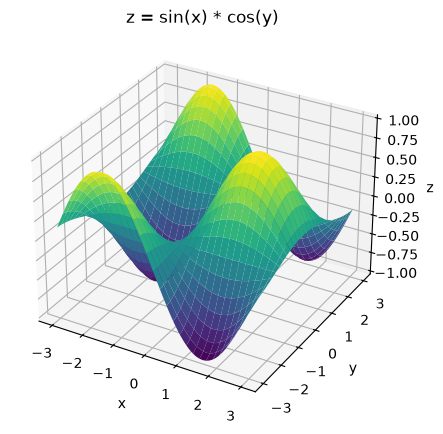

In [22]:
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('z = sin(x) * cos(y)')
plt.show()

The online resource has a project on drawing surfaces with NumPy and Matplotlib, using `plt.figure()`, `add_subplot(projection='3d')`, `plot_surface()`, the axis-label functions, `set_title()` and `plt.show()`.

[Back to the Table of Contents](#toc)

## <a name="11-18-special-numerical-values-in-numpy"></a>11.18 Special numerical values in NumPy

Some calculations give results that are not ordinary numbers. NumPy has special values for them:

| Value | Meaning | Typical cause |
|---|---|---|
| `np.inf` | Positive infinity | A positive number divided by zero (in NumPy) |
| `-np.inf` | Negative infinity | A negative number divided by zero; `np.log(0)` |
| `np.nan` | "Not a Number": undefined or invalid | `0/0`; the log of a negative number |

Older books also use `np.PINF` and `np.NINF`. These names were removed in NumPy 2.0; use `np.inf` and `-np.inf`.

[Back to the Table of Contents](#toc)

### <a name="example-15-inf-inf-and-nan"></a>Example 15: inf, -inf and nan

**What the code does.** It prints the three special values, and then asks NumPy for `log(0)` and `log(-1)`.

**Learning points**

1. `np.log(0)` gives `-inf` and `np.log(-1)` gives `nan`. NumPy does not stop the program; it prints a **RuntimeWarning** (the pink box below the cell) and carries on.
2. `np.nan` is not equal to anything, not even itself: `np.nan == np.nan` is `False`. To test for it, use `np.isnan()`.

In [23]:
import numpy as np
# Special Values in NumPy

# 1.  np.inf is a special floating point value that represents positive infinity. It is
# used to represent values that are larger than any finite number. For example
# if you divide a positive number by zero, you will get np.inf as a result.
print("Positive infinity:", np.inf) # Output: Positive infinity: inf

# 2.  -np.inf represents negative infinity. It is used to represent values that are
# smaller than any finite number. For example, if you divide a negative number
# by zero, you will get -np.inf as the result.
print("Negative infinity:", -np.inf)  # Output: Negative infinity: -inf

# 3.  np.nan stands for "Not a Number". It is used to represent undefined or
# unrepresentable values, such as the result of 0/0 or the logarithm of a
# negative number. np.nan is not equal to any value, including itself,
# which is why it is used to indicate invalid or missing data in computations.
print("Not a number:", np.nan)  # Output: Not a number: nan

print("log(0):", np.log(0))     # → log(0) is undefined and results in negative infinity
# Output: log(0): -inf
print("log(-1):", np.log(-1))   # → nan. Log of a negative number is not defined.
# Output: log(-1): nan

Positive infinity: inf
Negative infinity: -inf
Not a number: nan
log(0): -inf
log(-1): nan


/tmp/ipykernel_559/3076226441.py:20: RuntimeWarning: divide by zero encountered in log
  print("log(0):", np.log(0))     # → log(0) is undefined and results in negative infinity
/tmp/ipykernel_559/3076226441.py:22: RuntimeWarning: invalid value encountered in log
  print("log(-1):", np.log(-1))   # → nan. Log of a negative number is not defined.


[Back to the Table of Contents](#toc)

### <a name="try-it-testing-for-nan-and-inf"></a>Try it: testing for nan and inf

This cell is not in the book.

In [24]:
data = np.array([1.0, np.nan, 3.0, np.inf])
print("nan == nan ?", np.nan == np.nan)
print("isnan   :", np.isnan(data))
print("isinf   :", np.isinf(data))
print("isfinite:", np.isfinite(data))
print("Mean ignoring nan:", np.nanmean(np.array([1.0, np.nan, 3.0])))

nan == nan ? False
isnan   : [False  True False False]
isinf   : [False False False  True]
isfinite: [ True False  True False]
Mean ignoring nan: 2.0


[Back to the Table of Contents](#toc)

## <a name="11-19-basic-matrix-operations-in-numpy"></a>11.19 Basic matrix operations in NumPy

NumPy has a sub-module, `np.linalg`, for linear algebra on matrices. It helps you find important properties of a matrix, such as the determinant, the inverse, the rank and the norm.

| No. | Function | Purpose | Output | Condition | What it tells you |
|---|---|---|---|---|---|
| 1 | `A.T` | Transpose | A matrix (shape swapped) | Rows and columns swap | Used in ML, dot products |
| 2 | `np.trace(A)` | Sum of the diagonal elements | A number | Only the main diagonal is used | The "diagonal strength" of the matrix |
| 3 | `np.linalg.det(A)` | Determinant | A number | The matrix must be square | If det is not 0, the inverse exists |
| 4 | `np.linalg.inv(A)` | Inverse | A matrix (same shape) | det must not be 0 | Used to solve linear equations |
| 5 | `np.linalg.norm(A)` | Size of the matrix | A number | By default the Frobenius norm | Measures size or scale |
| 6 | `np.linalg.matrix_rank(A)` | Rank | An integer | At most min(rows, columns) | Rank less than n means the rows depend on each other |

[Back to the Table of Contents](#toc)

### <a name="example-16-transpose-determinant-inverse-norm-rank-and-matri"></a>Example 16: Transpose, determinant, inverse, norm, rank and matrix product

**What the code does.** For a 3 x 3 matrix `A` it prints the transpose, the determinant, the inverse, the Frobenius norm and the rank. Then it multiplies the inverse by `A` to check that the result is the identity matrix.

**How it works.**

- The **determinant** is a single number. If it is 0, the matrix is "singular" and has no inverse. Here it is 1 (NumPy shows `1.0000000000000004` because of rounding).
- The **inverse** B satisfies AB = BA = I.
- The **Frobenius norm** is the square root of the sum of the squares of all the elements. Here that is the square root of 60, about 7.746.
- The **rank** is the number of independent rows (or columns). 3 means all three rows are independent.
- `@` is the matrix multiplication operator. It is recommended over `np.matmul()`.

**Learning points**

1. `B @ A` gives the identity matrix, up to tiny rounding errors. Some zeros may print as numbers like `1e-16`.
2. `*` is **not** matrix multiplication. `A * B` multiplies element by element.

In [25]:
import numpy as np

A = np.array([
    [0, -3, -2],
    [1, -4, -2],
    [-3, 4, 1]
])

# 1. Transpose by swapping its rows with its columns.
print("Transpose:\n", A.T)

# 2.Determinant: Indicates that the matrix is invertible. If it is zero, it
# would mean that the matrix is singular and does not have an inverse.
print("Determinant:", np.linalg.det(A)) # Output: 1.0000000000000004

# 3. The inverse of A is B such that AB = BA = I, where I is identity matrix
print("Inverse:\n", np.linalg.inv(A))  # Output: [[ 4. -5. -2.]
#                                                 [ 5. -6. -2.]
#                                                 [-8.  9.  3.]]

# 4. Frobenius norm is a measure of the "size" of the matrix, calculated as
# square root of the sum of the absolute squares of its elements.
print("Frobenius norm:", np.linalg.norm(A))  # Output: 7.745966692414834

# 5. Rank is the dimension of the vector space generated by its rows or columns.
print("Rank:", np.linalg.matrix_rank(A))
# Output: 3. This means the rows (and columns) of A are linearly independent.

# 6. Matrix multiplication: A @ B. Using @ is recommended over np.matmul.
B = np.linalg.inv(A)
C = B @ A   # recommended over np.matmul
print("Product (should be identity):\n", C)
# Output: [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
#          [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
#          [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Transpose:
 [[ 0  1 -3]
 [-3 -4  4]
 [-2 -2  1]]
Determinant: 1.0000000000000004
Inverse:
 [[ 4. -5. -2.]
 [ 5. -6. -2.]
 [-8.  9.  3.]]
Frobenius norm: 7.745966692414834
Rank: 3
Product (should be identity):
 [[ 1.00000000e+00 -4.44089210e-15 -1.99840144e-15]
 [ 0.00000000e+00  1.00000000e+00 -8.88178420e-16]
 [ 4.44089210e-16  1.77635684e-15  1.00000000e+00]]


[Back to the Table of Contents](#toc)

### <a name="try-it-trace-and-compared-with"></a>Try it: trace, and * compared with @

This cell is not in the book.

In [26]:
print("Trace of A:", np.trace(A))          # 0 + (-4) + 1
print("A * A (element by element):\n", A * A)
print("A @ A (matrix product):\n", A @ A)

Trace of A: -3
A * A (element by element):
 [[ 0  9  4]
 [ 1 16  4]
 [ 9 16  1]]
A @ A (matrix product):
 [[ 3  4  4]
 [ 2  5  4]
 [ 1 -3 -1]]


The online resource gives a basic introduction to the mathematics of matrices and vectors: how a matrix transforms a vector. This helps if you go on to machine learning libraries.

[Back to the Table of Contents](#toc)

## <a name="11-20-solving-linear-equations-with-numpy"></a>11.20 Solving linear equations with NumPy

A system of linear equations can be written with three matrices:

| Name | Symbol | Holds |
|---|---|---|
| Coefficient matrix | A | The numbers in front of the variables |
| Variable vector | x | The unknowns x<sub>1</sub>, x<sub>2</sub>, x<sub>3</sub> |
| Constant vector | b | The numbers on the right-hand side |

Each equation a<sub>i1</sub>x<sub>1</sub> + a<sub>i2</sub>x<sub>2</sub> + a<sub>i3</sub>x<sub>3</sub> = b<sub>i</sub> is one row. Together they form **A·x = b**.

The signature is `np.linalg.solve(A, b)`. It returns `x` such that A·x = b. `A` must be square and non-singular (invertible).

[Back to the Table of Contents](#toc)

### <a name="example-17-solving-three-equations-in-three-unknowns"></a>Example 17: Solving three equations in three unknowns

**What the code does.** It solves

- 2x + 3y + z = 13
- x - y + 2z = 7
- 3x + 4y + z = 22

and then checks the answer by computing A·x and comparing it with b.

**How it works.** `np.linalg.solve()` uses LU decomposition, or a similar method, under the hood. It is faster and more accurate than computing the inverse and multiplying.

**Learning points**

1. The answer is x = 11, y = -2, z = -3. Check the first equation: 22 - 6 - 3 = 13.
2. Floating-point results may carry tiny errors, so compare them with `np.allclose()`, not with `==`.

![Solving a system of linear equations with NumPy](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-08-linear-solve.png)

In [27]:
import numpy as np

#2x + 3y + z = 13, x - y + 2z = 7, 3x + 4y + z = 22

# 1. Define the coefficient matrix A & vector b based on the system of equations
A = np.array([[2, 3, 1],
              [1, -1, 2],
              [3, 4, 1]])
b = np.array([13, 7, 22])

# 2. Solve the system of equations using np.linalg.solve(A, b). Returns x
# such that A.x = b. A must be square & non-singular (invertible) for this to
# work. The function uses LU decomposition or similar methods under the hood.
# x will contain the values of x, y, z that satisfy the equations
x = np.linalg.solve(A, b)
print('x->', x)

# 3. Verify the solution. np.dot(A, x) computes the matrix-vector product of
# A and x. If x is the correct solution to A.x = b, then it should equal b. Use
# np.allclose() to check if # two arrays are approximately equal to account
# for floating-point precision issues. It returns True if A.x is close to b
B = np.dot(A, x)
print('b->', B)
print('Is A.x == b?', np.allclose(B, b))

x-> [11. -2. -3.]
b-> [13.  7. 22.]
Is A.x == b? True


The online resource has a project on matrix-vector multiplication as a transformation: scaling, reflection and rotation, and how they are used in data science and ML.

[Back to the Table of Contents](#toc)

## <a name="11-21-eigenvalues-and-eigenvectors"></a>11.21 Eigenvalues and eigenvectors

- In linear algebra, a square matrix can be seen as a **transformation**. Take an n x n matrix A and a vector v with n rows and 1 column.
- Multiplying gives a new vector: w = A·v. Usually w points in a different direction from v.
- But for some special vectors, w is just v multiplied by a number λ (lambda): **A·v = λ·v**. Then w and v point along the same line; only the length changes.
- Such a v is an **eigenvector** of A, and λ is its **eigenvalue**. In words: an eigenvector is a vector whose direction is not changed by the transformation, only its size.

**An example.** Take A = [[2, 1], [1, 2]] and v = [1, -1]. Then A·v = [2 - 1, 1 - 2] = [1, -1] = v. So v is an eigenvector of A, with eigenvalue λ = 1.

A·v = λ·v can be rewritten as (A - λI)·v = 0, where I is the identity matrix. This has a non-zero solution v only if det(A - λI) = 0. Solving that equation gives the eigenvalues.

**An intuitive picture.**

- (a) Rotate a globe a little about its axis. Every point on the globe moves, except the points on the axis. So the axis is an eigenvector of the rotation, and its eigenvalue is 1 (its length does not change).
- (b) Now rotate the globe and also stretch it along its axis, so that it becomes an ellipsoid. The axis still keeps its direction, but its length changes. It is still an eigenvector, but now λ is not 1: λ > 1 if the globe is stretched along the axis, and λ < 1 if it is squashed.

[Back to the Table of Contents](#toc)

### <a name="try-it-eigenvalues-with-np-linalg-eig"></a>Try it: eigenvalues with np.linalg.eig()

This cell is not in the book. `np.linalg.eig(A)` returns two things: an array of eigenvalues, and a matrix whose **columns** are the matching eigenvectors (scaled to length 1). For the matrix of the example, the eigenvalues are 3 and 1. The cell then checks A·v = λ·v for each pair.

In [28]:
import numpy as np

A = np.array([[2, 1],
              [1, 2]])

values, vectors = np.linalg.eig(A)
print("Eigenvalues:", values)
print("Eigenvectors (as columns):\n", vectors)

for i in range(len(values)):
    v = vectors[:, i]
    print(f"lambda = {values[i]:.1f}: A @ v = {A @ v}, lambda * v = {values[i] * v}")

# The vector from the text
v = np.array([1, -1])
print("A @ [1, -1] =", A @ v)

Eigenvalues: [3. 1.]
Eigenvectors (as columns):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
lambda = 3.0: A @ v = [2.12132034 2.12132034], lambda * v = [2.12132034 2.12132034]
lambda = 1.0: A @ v = [-0.70710678  0.70710678], lambda * v = [-0.70710678  0.70710678]
A @ [1, -1] = [ 1 -1]


The online resource has more on eigenvalues and eigenvectors: an intuitive introduction, what makes eigenvectors special, eigen decomposition, visualising the components, a worked example, and a Python implementation.

[Back to the Table of Contents](#toc)

## <a name="11-22-introduction-to-singular-value-decomposition-svd"></a>11.22 Introduction to Singular Value Decomposition (SVD)

**Singular Value Decomposition** breaks any matrix into a product of three simpler matrices. For any m x n matrix A:

**A = U Σ V<sup>T</sup>**

| Part | Shape | What it is |
|---|---|---|
| U | m x m | An orthogonal matrix. Its columns are the **left singular vectors**. |
| Σ (Sigma) | m x n | A diagonal matrix of **singular values**: never negative, in decreasing order |
| V<sup>T</sup> | n x n | An orthogonal matrix. Its rows are the **right singular vectors**. |

Why SVD is so useful:

- **It works for every matrix.** Eigen decomposition needs a square matrix (and works best for symmetric ones). SVD works for any shape.
- **The singular values are ranked.** The first ones carry the most important structure of the data; the last ones carry little more than noise.
- So, by keeping only the largest few singular values, you get a **low-rank approximation**: a much smaller version of the data that keeps its essential shape. This is used for dimensionality reduction, signal processing, image compression and text analysis.

In NumPy: `U, S, Vt = np.linalg.svd(A, full_matrices=False)`. Note that `S` comes back as a 1D array of singular values, not as a matrix; use `np.diag(S)` to make the diagonal matrix.

[Back to the Table of Contents](#toc)

### <a name="try-it-svd-of-a-small-matrix"></a>Try it: SVD of a small matrix

This cell is not in the book. It decomposes a 3 x 2 matrix, rebuilds it from the three parts, and then makes a rank-1 approximation from the largest singular value alone.

In [29]:
import numpy as np

A = np.array([[3.0, 2.0],
              [2.0, 3.0],
              [2.0, -2.0]])

U, S, Vt = np.linalg.svd(A, full_matrices=False)
print("U shape:", U.shape, " S:", S, " Vt shape:", Vt.shape)

rebuilt = U @ np.diag(S) @ Vt
print("Rebuilt equals A?", np.allclose(rebuilt, A))

k = 1                                   # keep only the largest singular value
approx = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
print("Rank-1 approximation:\n", np.round(approx, 2))
print("Share of 'energy' kept:", round((S[:k]**2).sum() / (S**2).sum(), 3))

U shape: (3, 2)  S: [5. 3.]  Vt shape: (2, 2)
Rebuilt equals A? True
Rank-1 approximation:
 [[2.5 2.5]
 [2.5 2.5]
 [0.  0. ]]
Share of 'energy' kept: 0.735


The online resource has a full project on SVD: the mathematics of A = UΣV<sup>T</sup>, the roles of U, Σ and V, checking orthogonality and the order of the singular values, a Python implementation, truncated SVD with the top k singular values (Y = U<sub>k</sub>Σ<sub>k</sub>V<sub>k</sub><sup>T</sup>), and measuring how much information is kept using the Frobenius norm.

[Back to the Table of Contents](#toc)

## <a name="questions"></a>Questions

The chapter ends with three sets of questions; the answers are online:

- **Advanced topics and best practices** (10 questions): ufuncs, C-order and Fortran-order memory layout, how fancy indexing differs from slicing, `np.nan` and missing data, vectorized string processing, `np.save()` and `np.load()`, structured arrays, the ellipsis `...`, `np.vectorize` and its main limitation, and why NumPy is the "lingua franca" of Python data science.
- **Scripting questions** (30 questions): most of them use the examples in this notebook.
- **Advanced / best practices, external topics** (10 questions): `np.newaxis`, `np.genfromtxt`, `np.convolve`, structured arrays, `np.clip`, `np.memmap`, `np.unique`, `np.tile`, `np.allclose` and `np.frompyfunc`.

[Back to the Table of Contents](#toc)

## <a name="beyond-the-text-image-compression-with-svd"></a>Beyond the text: image compression with SVD

This project from the book puts SVD to work. An image is really a big grid of numbers, that is, a matrix. SVD splits it into its singular values. The large ones hold the essential structure of the picture; the small ones are mostly fine detail and noise. So if we keep only a few singular values, we can store a much smaller version of the image that still looks like the original.

The question it explores: how much information do you need to recognise an image? What is the link between the rank (the number of singular values kept) and how clear the picture looks? Where is the "critical compression threshold", below which the picture is no longer recognisable?

**The workflow**

| Step | Name | What happens |
|---|---|---|
| 1 | Acquisition | Fetch an image from a web URL (or your own drive) |
| 2 | Pre-processing | Turn the colour image into a 2D grayscale matrix, with the Pillow (PIL) library |
| 3 | Decomposition | Split the matrix into U, Σ and V<sup>T</sup> with `np.linalg.svd()` |
| 4 | Compression | Keep only the top singular values; here, 1/20th of them |
| 5 | Reconstruction | Multiply the kept parts back together and show the images side by side with Matplotlib |

[Back to the Table of Contents](#toc)

### <a name="example-18-compressing-an-image-with-svd"></a>Example 18: Compressing an image with SVD

**What the code does.** It downloads the NumPy logo, converts it to grayscale, turns it into a matrix, decomposes it with SVD, keeps only 5% of the singular values, rebuilds the image, and shows three pictures: the original, the grayscale version, and the compressed version.

**How it works.**

- `requests.get(url)` downloads the file, and `Image.open(BytesIO(response.content))` turns the raw bytes into an image. If the download fails, the `except` block makes a random 500 x 500 image instead, so the rest of the script still runs.
- `img.convert('L')` makes an 8-bit grayscale image ("L" stands for luminance).
- `np.asarray(img_gray)` turns the image directly into a NumPy matrix. This modern method is faster and simpler than the older `getdata()` approach with lists.
- `np.linalg.svd(img_mat, full_matrices=False)` gives U, S and Vt. `full_matrices=False` keeps only the parts that are needed, which saves memory.
- `k = int(len(S) / 20)` keeps 1/20th of the singular values. The logo is 650 pixels high, so k = 32.
- `np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))` rebuilds the image from the first k columns of U, the first k singular values, and the first k rows of Vt.

**Learning points**

1. With only 32 of 650 singular values, the logo is still clearly readable.
2. Storing U<sub>k</sub>, S<sub>k</sub> and Vt<sub>k</sub> takes k x (height + width + 1) numbers instead of height x width. That is the saving.
3. **Try it:** change 20 to 100 (so k is 6), or to 5 (so k is 130), and compare the pictures.

This cell needs an internet connection, which Colab has.

![The steps of image compression with SVD](https://raw.githubusercontent.com/ag999git/001-Python-book-2026/main/resources/ch-11-nb-09-svd-compression.png)

Original Dimensions: Width=1445, Height=650


Total Singular Values: 650 | Retained for Compression (k): 32


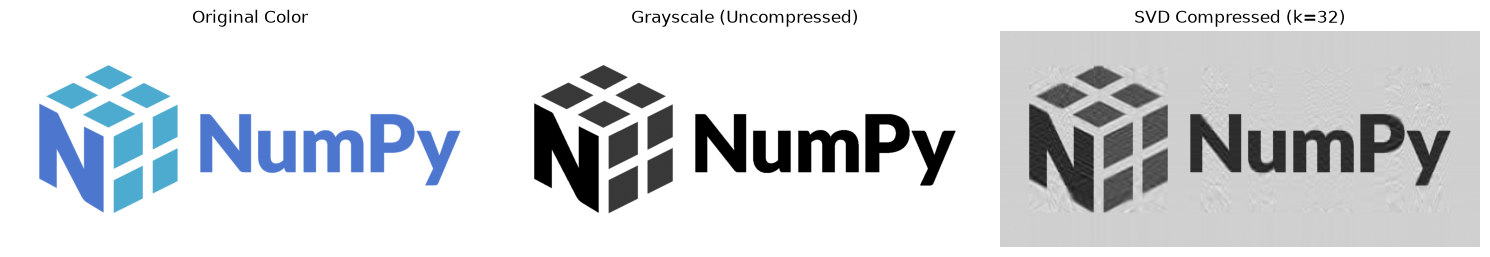

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# --- 1. Load Image (Local Path or Web Link) ---
# Replace this URL with any image link (e.g., from Unsplash or GitHub)
url = "https://raw.githubusercontent.com/numpy/numpy/main/branding/logo/primary/numpylogo.png"

try:
    response = requests.get(url)  # Fetch image from the internet
    img = Image.open(BytesIO(response.content))  # raw data → image format
except:
    print("Web link failed, please check URL or internet connection.")
    # Fallback: create a dummy array if the link fails
    img = Image.fromarray(np.uint8(np.random.rand(500,500)*255))

width, height = img.size
print(f"Original Dimensions: Width={width}, Height={height}")

# --- 2. Color Conversion ---
# 'L' mode converts image to grayscale (8-bit pixels, black and white)
img_gray = img.convert('L')

# --- 3. Matrix Conversion (The Modern Way) ---
# Instead of getdata() and lists, np.asarray() is much faster and more direct
img_mat = np.asarray(img_gray)

# --- 4. SVD Decomposition ---
# U: Left singular vectors (Rotations)
# S: Singular values (Importance/Energy of each feature)
# Vt: Right singular vectors (Rotations)
U, S, Vt = np.linalg.svd(img_mat, full_matrices=False)

# --- 5. Compression / Dimension Reduction ---
# We define 'k' as the number of singular values to keep.
# Let's use 1/20th (5%) of the available singular values.
k = int(len(S) / 20)
print(f"Total Singular Values: {len(S)} | Retained for Compression (k): {k}")

# Reconstruct the matrix using only the top 'k' components
# Formula: U_k * Sigma_k * Vt_k
img_compressed = np.dot(U[:, :k], np.dot(np.diag(S[:k]), Vt[:k, :]))

# --- 6. Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: Original Color
axes[0].imshow(img)
axes[0].set_title("Original Color")
axes[0].axis('off')

# Subplot 2: Grayscale Baseline
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Grayscale (Uncompressed)")
axes[1].axis('off')

# Subplot 3: SVD Compressed
axes[2].imshow(img_compressed, cmap='gray')
axes[2].set_title(f"SVD Compressed (k={k})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

[Back to the Table of Contents](#toc)

### <a name="notes-on-example-18"></a>Notes on Example 18

- **Try it:** use a photograph instead of a logo. Paste the link of any `.jpg` or `.png` image into `url`. Photographs usually need a larger k than a simple logo.
- **Your own image:** in Colab, upload a picture with the Files panel (the folder icon), and replace the `try` block with `img = Image.open("my_photo.jpg")`.
- The online resource gives a step-by-step explanation of the script, and notes on the libraries used: matplotlib, PIL, requests and io.

[Back to the Table of Contents](#toc)

## <a name="beyond-the-book"></a>Beyond the Book

These short extras are not in the book. Skip them on the first reading.

[Back to the Table of Contents](#toc)

### <a name="the-modern-random-generator-default-rng"></a>The modern random generator: default_rng()

NumPy now recommends a **Generator** object instead of the global `np.random.seed()`. Each generator has its own state, so two parts of a program cannot disturb each other's random numbers.

In [31]:
import numpy as np

rng = np.random.default_rng(seed=42)
print("floats  :", rng.random(3))
print("integers:", rng.integers(1, 5, size=(2, 3)))
print("normal  :", rng.normal(0, 1, 3))

rng_a = np.random.default_rng(seed=7)       # two generators, same seed
rng_b = np.random.default_rng(seed=7)
print("Same numbers from the same seed?", np.array_equal(rng_a.random(3), rng_b.random(3)))

floats  : [0.77395605 0.43887844 0.85859792]
integers: [[1 3 1]
 [1 3 4]]
normal  : [ 0.1278404  -0.31624259 -0.01680116]
Same numbers from the same seed? True


[Back to the Table of Contents](#toc)

### <a name="a-few-handy-functions-unique-clip-argmax-and-newaxis"></a>A few handy functions: unique, clip, argmax and newaxis

In [32]:
marks = np.array([85, 32, 78, 92, 25, 60, 78, 92])

values, counts = np.unique(marks, return_counts=True)
print("Unique marks:", values, "counts:", counts)

print("Clipped to 40..90:", np.clip(marks, 40, 90))
print("Position of the top mark:", np.argmax(marks))

row = np.array([1, 2, 3])
col = row[:, np.newaxis]             # turns a 1D array into a column vector
print("Column vector shape:", col.shape)
print("Outer table by broadcasting:\n", col * row)

Unique marks: [25 32 60 78 85 92] counts: [1 1 1 2 1 2]
Clipped to 40..90: [85 40 78 90 40 60 78 90]
Position of the top mark: 3
Column vector shape: (3, 1)
Outer table by broadcasting:
 [[1 2 3]
 [2 4 6]
 [3 6 9]]


[Back to the Table of Contents](#toc)

### <a name="saving-and-loading-arrays"></a>Saving and loading arrays

`np.save()` writes an array to a binary `.npy` file, keeping its shape and type exactly. `np.load()` reads it back. This is faster and safer than saving numbers as text.

In [33]:
grid = np.arange(12).reshape(3, 4)
np.save("grid.npy", grid)
loaded = np.load("grid.npy")
print(loaded)
print("Same array?", np.array_equal(grid, loaded), "| dtype:", loaded.dtype)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Same array? True | dtype: int64


[Back to the Table of Contents](#toc)